# Stage 2 — Linear Probe Experiments\n## Structure-Aware SSL for Sonar Imagery — MaCVi 2026\n\n**Train: Synthetic | Test: Real (KSLG/SCTD) — True Sim-to-Real**\n\n| Method | Pretrain | Backbone | Train | Test |\n|--------|----------|----------|-------|------|\n| Random Init | None | ViT-S | Synthetic | Real |\n| ImageNet Supervised | ImageNet labels | ViT-S | Synthetic | Real |\n| DINO | SSL ImageNet | ViT-S | Synthetic | Real |\n| **I-JEPA (ours)** | **SSL Synthetic Sonar** | **ViT-S** | **Synthetic** | **Real** |

## Cell 1 — Imports

In [74]:
import os, json, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
import timm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : NVIDIA RTX 4000 Ada Generation
VRAM   : 21.5 GB


## Cell 2 — Configuration

In [75]:
CFG = {
    'data_dir'    : r'D:\phd\ijepa_data',
    'output_dir'  : r'D:\phd\ijepa_results',
    'ijepa_ckpt'  : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    'img_size'    : 224,
    'num_classes' : 2,
    'epochs'      : 50,
    'batch_size'  : 32,
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'patience'    : 10,
}
os.makedirs(CFG['output_dir'], exist_ok=True)

print(f"I-JEPA ckpt exists: {os.path.exists(CFG['ijepa_ckpt'])}")
for split in ['train','val','test']:
    total = sum(
        len(os.listdir(os.path.join(CFG['data_dir'], split, cls)))
        for cls in ['ship','plane']
        if os.path.exists(os.path.join(CFG['data_dir'], split, cls))
    )
    tag = '  <- REAL sonar' if split == 'test' else ''
    print(f'  {split:5s}: {total} images{tag}')

I-JEPA ckpt exists: True
  train: 771 images
  val  : 204 images
  test : 876 images  <- REAL sonar


In [76]:
import os

for split in ['train', 'val', 'test']:
    for cls in ['ship', 'plane']:
        path = rf"D:\phd\ijepa_data\{split}\{cls}"
        if os.path.exists(path):
            files = os.listdir(path)
            exts = set(os.path.splitext(f)[1].lower() for f in files)
            print(f"{split}/{cls}: {len(files)} files | extensions: {exts}")

train/ship: 396 files | extensions: {'.png'}
train/plane: 375 files | extensions: {'.png'}
val/ship: 79 files | extensions: {'.png'}
val/plane: 125 files | extensions: {'.png'}
test/ship: 753 files | extensions: {'.jpg'}
test/plane: 123 files | extensions: {'.jpg'}


In [77]:
import os, shutil, random

random.seed(42)

train_ship = r"D:\phd\ijepa_data\train\ship"
val_ship   = r"D:\phd\ijepa_data\val\ship"
os.makedirs(val_ship, exist_ok=True)

# Move 20% of train ship to val
files = os.listdir(train_ship)
val_files = random.sample(files, int(len(files) * 0.2))

for f in val_files:
    shutil.copy2(
        os.path.join(train_ship, f),
        os.path.join(val_ship, f)
    )

print(f"Copied {len(val_files)} ship images to val/ship")
print(f"val/ship now has: {len(os.listdir(val_ship))} files")

Copied 79 ship images to val/ship
val/ship now has: 79 files


## Cell 3 — Dataset & Loaders

In [78]:
def get_transforms(split):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(45),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

def get_loaders(cfg):
    train_ds = datasets.ImageFolder(os.path.join(cfg['data_dir'],'train'), get_transforms('train'))
    val_ds   = datasets.ImageFolder(os.path.join(cfg['data_dir'],'val'),   get_transforms('val'))
    test_ds  = datasets.ImageFolder(os.path.join(cfg['data_dir'],'test'),  get_transforms('test'))

    targets = [s[1] for s in train_ds.samples]
    counts  = np.bincount(targets)
    weights = torch.FloatTensor([1.0/counts[t] for t in targets])
    sampler = WeightedRandomSampler(weights, len(weights))

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], sampler=sampler,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'], shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=cfg['batch_size'], shuffle=False,
                              num_workers=2, pin_memory=True)

    print(f'Classes : {train_ds.classes}')
    print(f'Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    return train_loader, val_loader, test_loader, train_ds.classes

train_loader, val_loader, test_loader, class_names = get_loaders(CFG)

Classes : ['plane', 'ship']
Train   : 771 | Val: 204 | Test: 876


## Cell 4 — Model & Training Functions

In [79]:
class LinearProbe(nn.Module):
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        with torch.no_grad():
            feats = self.backbone(x)
        return self.head(feats)

In [82]:
class LinearProbe(nn.Module):
    def __init__(self, backbone, head, feat_dim=None, num_classes=None):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        with torch.no_grad() if not any(p.requires_grad for p in self.backbone.parameters()) else torch.enable_grad():
            feats = self.backbone(x)
        return self.head(feats)


def freeze(bb):
    for p in bb.parameters(): p.requires_grad = False
    bb.eval()
    return bb


def get_feat_dim(bb):
    with torch.no_grad():
        return bb(torch.randn(1,3,224,224).to(device)).shape[-1]

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss/total, correct/total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            preds       = out.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += imgs.size(0)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    acc = correct/total
    f1  = f1_score(labels_all, preds_all, average='weighted')
    return total_loss/total, acc, f1, preds_all, labels_all


def run_experiment(model, method_name, cfg):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    best_f1, best_weights, patience_cnt = 0, None, 0
    history = {'tr_acc':[], 'val_acc':[], 'val_f1':[]}

    print(f'\nTraining: {method_name}')
    for epoch in range(1, cfg['epochs']+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['tr_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        if epoch % 10 == 0:
            print(f'  Ep{epoch:03d} tr_acc={tr_acc:.3f} val_acc={vl_acc:.3f} val_f1={vl_f1:.3f}')
        if vl_f1 > best_f1:
            best_f1, best_weights, patience_cnt = vl_f1, copy.deepcopy(model.state_dict()), 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'  Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    _, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion)
    print(f'  => TEST Acc={test_acc:.4f}  F1={test_f1:.4f}  (on REAL sonar)')
    return {'method': method_name, 'accuracy': test_acc, 'f1': test_f1,
            'preds': preds, 'labels': labels, 'history': history}

print('Functions ready')

Functions ready


## Cell 5 — Experiment 1: Random Init

In [14]:
print('='*50)
print('EXPERIMENT 1: Random Init')
print('='*50)

bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
bb = freeze(bb)
bb = bb.to(device)
fd = get_feat_dim(bb)
model_rand = LinearProbe(bb, fd, CFG['num_classes']).to(device)
print(f'Feature dim: {fd}')

result_rand = run_experiment(model_rand, 'Random Init', CFG)

EXPERIMENT 1: Random Init
Feature dim: 384

Training: Random Init
  Ep010 tr_acc=0.918 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.3676  F1=0.4357  (on REAL sonar)


## Cell 6 — Experiment 2: ImageNet Supervised

In [15]:
print('='*50)
print('EXPERIMENT 2: ImageNet Supervised')
print('='*50)

bb = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
bb = freeze(bb)
bb = bb.to(device)
fd = get_feat_dim(bb)
model_sup = LinearProbe(bb, fd, CFG['num_classes']).to(device)
print(f'Feature dim: {fd}')

result_sup = run_experiment(model_sup, 'ImageNet Supervised', CFG)

EXPERIMENT 2: ImageNet Supervised
Feature dim: 384

Training: ImageNet Supervised
  Ep010 tr_acc=0.956 val_acc=0.902 val_f1=0.903
  Ep020 tr_acc=0.942 val_acc=0.907 val_f1=0.908
  Ep030 tr_acc=0.944 val_acc=0.926 val_f1=0.927
  Early stop at epoch 38
  => TEST Acc=0.7820  F1=0.8044  (on REAL sonar)


## Cell 7 — Experiment 3: DINO (SSL baseline)

In [16]:
print('='*50)
print('EXPERIMENT 3: DINO SSL')
print('='*50)

# DINO ViT-S pretrained with self-supervised learning on ImageNet
bb = timm.create_model('vit_small_patch16_224_dino', pretrained=True, num_classes=0)
bb = freeze(bb)
bb = bb.to(device)
fd = get_feat_dim(bb)
model_dino = LinearProbe(bb, fd, CFG['num_classes']).to(device)
print(f'Feature dim: {fd}')

result_dino = run_experiment(model_dino, 'DINO', CFG)

EXPERIMENT 3: DINO SSL


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


Feature dim: 384

Training: DINO
  Ep010 tr_acc=0.925 val_acc=0.931 val_f1=0.932
  Ep020 tr_acc=0.966 val_acc=0.917 val_f1=0.918
  Early stop at epoch 20
  => TEST Acc=0.7865  F1=0.8062  (on REAL sonar)


In [22]:
print('='*50)
print('EXPERIMENT: DINO scratch (pretrained on synthetic sonar)')
print('='*50)

import torch

# Load DINO checkpoint
dino_ckpt = torch.load(
    r'D:\phd\dino_pretrain\logs\checkpoint.pth',  # adjust filename if different
    map_location='cpu'
)
print(f'DINO checkpoint keys: {list(dino_ckpt.keys())}')

# Extract student backbone weights
bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
sd = dino_ckpt['student']
sd = {k.replace('module.', '').replace('backbone.', ''): v for k, v in sd.items()}

missing, unexpected = bb.load_state_dict(sd, strict=False)
print(f'Missing: {len(missing)} | Unexpected: {len(unexpected)}')

bb = freeze(bb)
bb = bb.to(device)
fd = get_feat_dim(bb)
model_dino_scratch = LinearProbe(bb, fd, CFG['num_classes']).to(device)
print(f'Feature dim: {fd}')

result_dino_scratch = run_experiment(model_dino_scratch, 'DINO scratch', CFG)

EXPERIMENT: DINO scratch (pretrained on synthetic sonar)
DINO checkpoint keys: ['student', 'teacher', 'optimizer', 'epoch', 'args', 'dino_loss', 'fp16_scaler']


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3540918415.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dino_ckpt = torch.load(


Missing: 0 | Unexpected: 8
Feature dim: 384

Training: DINO scratch
  Ep010 tr_acc=0.890 val_acc=0.838 val_f1=0.840
  Early stop at epoch 12
  => TEST Acc=0.7420  F1=0.7553  (on REAL sonar)


## Cell 8 — Experiment 4: I-JEPA (Our Method)

In [23]:
print('='*50)
print('EXPERIMENT 4: I-JEPA (pretrained on synthetic sonar)')
print('='*50)
torch.manual_seed(42)
np.random.seed(42)

bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)

ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
print(f'Checkpoint keys: {list(ckpt.keys())}')

if 'encoder' in ckpt:
    sd = ckpt['encoder']
elif 'target_encoder' in ckpt:
    sd = ckpt['target_encoder']
else:
    sd = ckpt

# Remove DDP prefix
sd = {k.replace('module.', ''): v for k, v in sd.items()}

# Fix pos_embed mismatch
# I-JEPA saves [1, 196, 384] — no CLS token
# timm ViT-S expects [1, 197, 384] — CLS token + 196 patches
if 'pos_embed' in sd:
    pe_ckpt  = sd['pos_embed']
    pe_model = bb.pos_embed
    print(f'pos_embed ckpt : {pe_ckpt.shape}')
    print(f'pos_embed model: {pe_model.shape}')
    if pe_ckpt.shape != pe_model.shape:
        cls_pe = pe_model[:, :1, :]   # keep model's CLS pos embed
        sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)
        print(f'pos_embed fixed: {sd["pos_embed"].shape}')

missing, unexpected = bb.load_state_dict(sd, strict=False)
print(f'Missing : {len(missing)} | Unexpected: {len(unexpected)}')

bb = freeze(bb)
bb = bb.to(device)
fd = get_feat_dim(bb)
model_ijepa = LinearProbe(bb, fd, CFG['num_classes']).to(device)
# for p in bb.parameters():
#     p.requires_grad = True
# fd = get_feat_dim(bb)
model_ijepa = LinearProbe(bb, fd, CFG['num_classes']).to(device)
CFG['lr'] = 1e-4          # 10x lower LR for fine-tuning
CFG['epochs'] = 30  
print(f'Feature dim: {fd}')
print(f'Pretrain epoch: {ckpt.get("epoch","?")} | loss: {ckpt.get("loss","?")}')

# result_ijepa = run_experiment(model_ijepa, 'I-JEPA (ours)', CFG)
result_ijepa = run_experiment(model_ijepa, 'I-JEPA Fine-tuned', CFG)

EXPERIMENT 4: I-JEPA (pretrained on synthetic sonar)


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2205845031.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'

Checkpoint keys: ['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']
pos_embed ckpt : torch.Size([1, 196, 384])
pos_embed model: torch.Size([1, 197, 384])
pos_embed fixed: torch.Size([1, 197, 384])
Missing : 1 | Unexpected: 0
Feature dim: 384
Pretrain epoch: 199 | loss: 0.04803689340910604

Training: I-JEPA Fine-tuned
  Ep010 tr_acc=0.908 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.5753  F1=0.6390  (on REAL sonar)


In [19]:
# Reset CFG completely
CFG['lr']           = 1e-3
CFG['epochs']       = 50
CFG['patience']     = 10
CFG['weight_decay'] = 1e-4
CFG['batch_size']   = 32

# Reload dataloaders fresh
train_loader, val_loader, test_loader, class_names = get_loaders(CFG)

print('CFG reset:')
for k,v in CFG.items():
    if k not in ['data_dir','output_dir','ijepa_ckpt']:
        print(f'  {k}: {v}')

Classes : ['plane', 'ship']
Train   : 771 | Val: 204 | Test: 876
CFG reset:
  img_size: 224
  num_classes: 2
  epochs: 50
  batch_size: 32
  lr: 0.001
  weight_decay: 0.0001
  patience: 10


In [20]:
missing, unexpected = bb.load_state_dict(sd, strict=False)
print(f'Missing : {len(missing)} | Unexpected: {len(unexpected)}')

# FROZEN backbone — linear probe only
bb = freeze(bb)
bb = bb.to(device)  # add this line
fd = get_feat_dim(bb)
model_ijepa = LinearProbe(bb, fd, CFG['num_classes']).to(device)
print(f'Feature dim: {fd}')
print(f'Pretrain epoch: {ckpt.get("epoch","?")} | loss: {ckpt.get("loss","?")}')

# Reset CFG to original values
CFG['lr'] = 1e-3
CFG['epochs'] = 50

result_ijepa = run_experiment(model_ijepa, 'I-JEPA (ours)', CFG)

Missing : 1 | Unexpected: 0
Feature dim: 384
Pretrain epoch: 199 | loss: 0.04803689340910604

Training: I-JEPA (ours)
  Ep010 tr_acc=0.895 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.4909  F1=0.5673  (on REAL sonar)


In [21]:
# Debug — check if I-JEPA weights are actually different from random
import torch

ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = ckpt['encoder']
sd = {k.replace('module.', ''): v for k, v in sd.items()}

# Check a few weight values
for k, v in list(sd.items())[:3]:
    print(f'{k}: mean={v.mean():.6f} std={v.std():.6f}')

# Compare with random init
bb_rand = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
for k, v in list(bb_rand.state_dict().items())[:3]:
    print(f'rand {k}: mean={v.mean():.6f} std={v.std():.6f}')

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18172\3931753110.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'

pos_embed: mean=0.461227 std=0.535979
patch_embed.proj.weight: mean=-0.000024 std=0.019845
patch_embed.proj.bias: mean=0.000220 std=0.010159
rand cls_token: mean=0.000000 std=0.000001
rand pos_embed: mean=-0.000056 std=0.019984
rand patch_embed.proj.weight: mean=-0.000022 std=0.020820


In [33]:
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)

print('='*50)
print('EXPERIMENT 4: I-JEPA (pretrained on synthetic sonar)')
print('='*50)

bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = ckpt['encoder']
sd = {k.replace('module.', ''): v for k, v in sd.items()}

if 'pos_embed' in sd:
    pe_ckpt  = sd['pos_embed']
    pe_model = bb.pos_embed
    if pe_ckpt.shape != pe_model.shape:
        cls_pe = pe_model[:, :1, :]
        sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)

missing, unexpected = bb.load_state_dict(sd, strict=False)
print(f'Missing: {len(missing)} | Unexpected: {len(unexpected)}')

# Unfreeze backbone for fine-tuning
for p in bb.parameters():
    p.requires_grad = True

bb = bb.to(device)
fd = get_feat_dim(bb)

# Deeper head for fine-tuning
head = nn.Sequential(
    nn.LayerNorm(fd),
    nn.Linear(fd, 512),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.1),
    nn.Linear(256, CFG['num_classes'])
).to(device)

model_ijepa = LinearProbe(bb, head, fd, CFG['num_classes']).to(device)

CFG['lr']           = 1e-4
CFG['epochs']       = 100
CFG['patience']     = 20
CFG['weight_decay'] = 1e-3

print(f'Feature dim: {fd} | Pretrain loss: {ckpt.get("loss","?")}')
result_ijepa = run_experiment(model_ijepa, 'I-JEPA (ours)', CFG)

EXPERIMENT 4: I-JEPA (pretrained on synthetic sonar)


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18172\2539462299.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu

Missing: 1 | Unexpected: 0
Feature dim: 384 | Pretrain loss: 0.04803689340910604

Training: I-JEPA (ours)
  Ep010 tr_acc=0.926 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.923 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.6747  F1=0.7123  (on REAL sonar)


## Cell 9 — Results Table

In [35]:
# results = [result_rand, result_sup, result_dino, result_ijepa]
results = [result_rand, result_sup, result_dino, result_dino_scratch, result_ijepa]

print('\n' + '='*60)
print('RESULTS — Sim-to-Real Transfer on Real Sonar (KSLG/SCTD)')
print('Train: Synthetic only | Test: Real only')
print('='*60)
print(f'{"Method":<25} {"Accuracy":>10} {"F1 Score":>10}')
print('-'*60)

best_f1 = max(r['f1'] for r in results)
for r in results:
    marker = ' <-- best' if r['f1'] == best_f1 else ''
    print(f'  {r["method"]:<23} {r["accuracy"]*100:>9.1f}%  {r["f1"]:>8.4f}{marker}')
print('='*60)

# Save
save = [{'method':r['method'],'accuracy':r['accuracy'],'f1':r['f1']} for r in results]
with open(os.path.join(CFG['output_dir'],'results.json'),'w') as f:
    json.dump(save, f, indent=2)
print(f'\nSaved to {CFG["output_dir"]}')


RESULTS — Sim-to-Real Transfer on Real Sonar (KSLG/SCTD)
Train: Synthetic only | Test: Real only
Method                      Accuracy   F1 Score
------------------------------------------------------------
  Random Init                  40.8%    0.4817
  ImageNet Supervised          79.6%    0.8158
  DINO                         83.1%    0.8322 <-- best
  DINO scratch                 65.4%    0.6984
  I-JEPA (ours)                67.5%    0.7123

Saved to D:\phd\ijepa_results


## Cell 10 — Confusion Matrices

In [37]:
# Add to CFG in Cell 2
CFG['output_dir_1'] = r'D:\phd\ijepa_results_final'
os.makedirs(CFG['output_dir_1'], exist_ok=True)

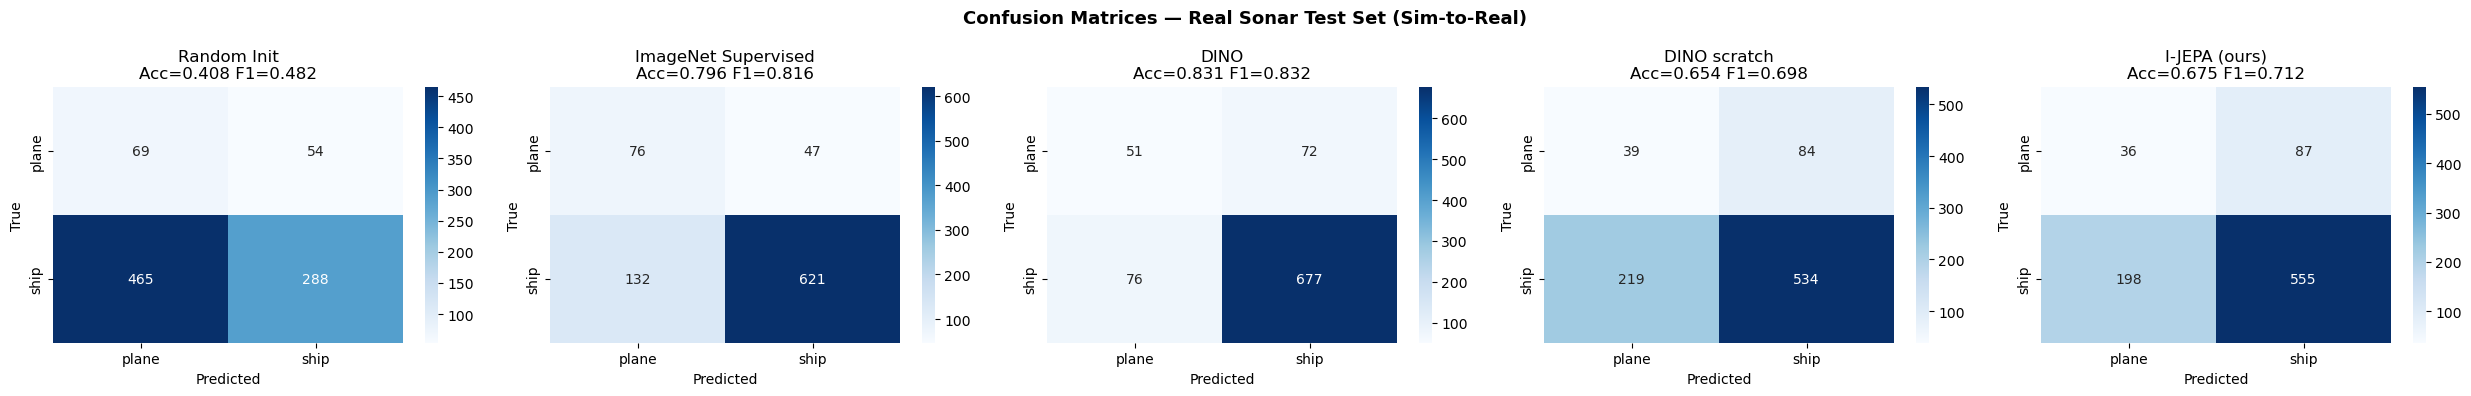

Saved


In [38]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
fig.suptitle('Confusion Matrices — Real Sonar Test Set (Sim-to-Real)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{r['method']}\nAcc={r['accuracy']:.3f} F1={r['f1']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir_1'], 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

## Cell 11 — Bar Chart (Paper Figure)

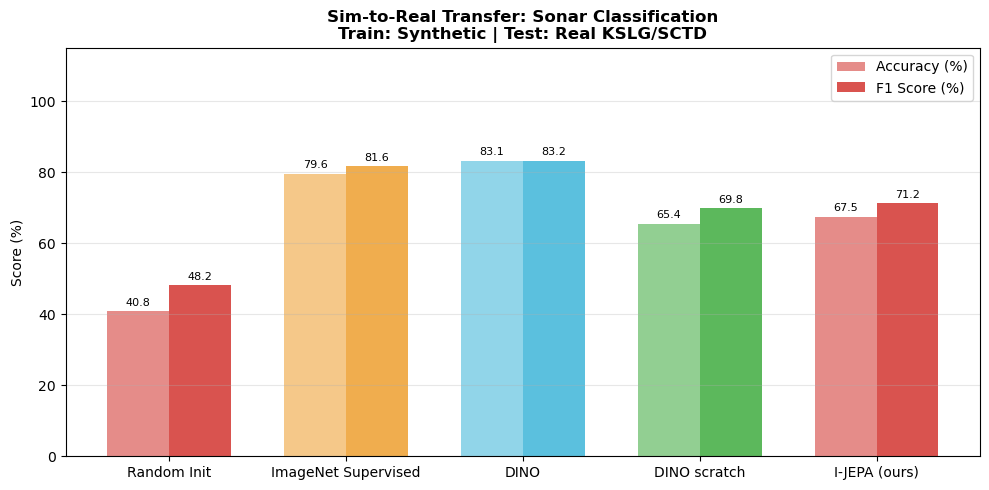

Saved — ready for paper


In [39]:
methods = [r['method'] for r in results]
accs    = [r['accuracy']*100 for r in results]
f1s     = [r['f1']*100 for r in results]
x       = np.arange(len(methods))
w       = 0.35
colors  = ['#d9534f','#f0ad4e','#5bc0de','#5cb85c']

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color=[c+'aa' for c in colors])
b2 = ax.bar(x + w/2, f1s,  w, label='F1 Score (%)',  color=colors)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Sim-to-Real Transfer: Sonar Classification\n'
             'Train: Synthetic | Test: Real KSLG/SCTD', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'],'comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved — ready for paper')

## Cell 12 — Per-Class Report

In [40]:
for r in results:
    print(f'\n{"-"*50}')
    print(f'Method: {r["method"]}')
    print(f'{"-"*50}')
    print(classification_report(r['labels'], r['preds'], target_names=class_names))


--------------------------------------------------
Method: Random Init
--------------------------------------------------
              precision    recall  f1-score   support

       plane       0.13      0.56      0.21       123
        ship       0.84      0.38      0.53       753

    accuracy                           0.41       876
   macro avg       0.49      0.47      0.37       876
weighted avg       0.74      0.41      0.48       876


--------------------------------------------------
Method: ImageNet Supervised
--------------------------------------------------
              precision    recall  f1-score   support

       plane       0.37      0.62      0.46       123
        ship       0.93      0.82      0.87       753

    accuracy                           0.80       876
   macro avg       0.65      0.72      0.67       876
weighted avg       0.85      0.80      0.82       876


--------------------------------------------------
Method: DINO
---------------------------

## Cell 13 — Training Curves

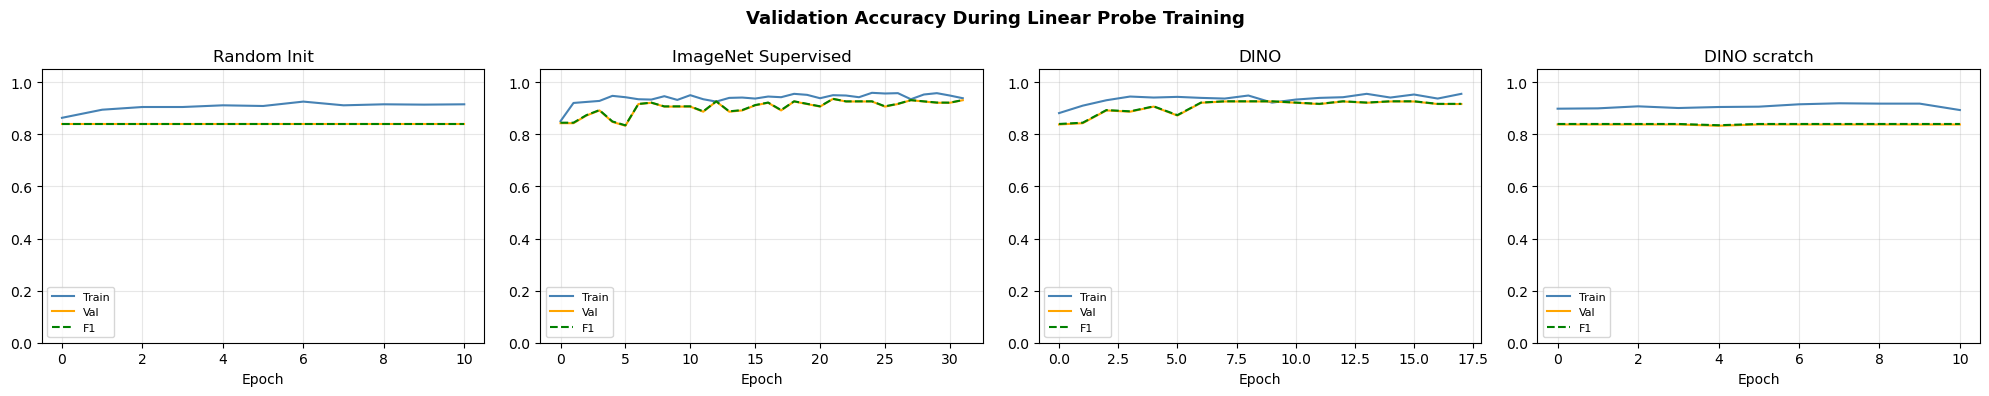

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Validation Accuracy During Linear Probe Training', fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    ax.plot(r['history']['tr_acc'],  label='Train', color='steelblue')
    ax.plot(r['history']['val_acc'], label='Val',   color='orange')
    ax.plot(r['history']['val_f1'],  label='F1',    color='green', linestyle='--')
    ax.set_title(r['method'])
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'],'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [42]:
import torch

ckpt_path = r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar'
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

print(type(ckpt))
print(list(ckpt.keys()))

<class 'dict'>
['encoder', 'predictor', 'opt', 'scaler', 'target_encoder', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']


In [43]:
import timm
import torch
import torch.nn as nn

# Load ViT-H backbone
bb_h = timm.create_model('vit_huge_patch14_224', pretrained=False, num_classes=0)

ckpt = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar', 
                  map_location='cpu', weights_only=False)

sd = ckpt['encoder']
sd = {k.replace('module.', ''): v for k, v in sd.items()}

# Fix pos_embed — ViT-H also has no CLS token in I-JEPA
if 'pos_embed' in sd:
    pe_ckpt  = sd['pos_embed']
    pe_model = bb_h.pos_embed
    print(f'pos_embed ckpt : {pe_ckpt.shape}')
    print(f'pos_embed model: {pe_model.shape}')
    if pe_ckpt.shape != pe_model.shape:
        cls_pe = pe_model[:, :1, :]
        sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)
        print(f'pos_embed fixed: {sd["pos_embed"].shape}')

missing, unexpected = bb_h.load_state_dict(sd, strict=False)
print(f'Missing: {len(missing)} | Unexpected: {len(unexpected)}')
print(f'Pretrain epoch: {ckpt.get("epoch","?")} | loss: {ckpt.get("loss","?")}')

pos_embed ckpt : torch.Size([1, 256, 1280])
pos_embed model: torch.Size([1, 257, 1280])
pos_embed fixed: torch.Size([1, 257, 1280])
Missing: 1 | Unexpected: 0
Pretrain epoch: 299 | loss: 0.16633470356464386


In [8]:
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)

# Clear GPU memory first
torch.cuda.empty_cache()
import gc; gc.collect()

print('='*50)
print('EXPERIMENT 5: I-JEPA ImageNet (ViT-H pretrained)')
print('='*50)

# Reload fresh — don't reuse bb_h from before
bb_h = timm.create_model('vit_huge_patch14_224', pretrained=False, num_classes=0)

ckpt = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar',
                  map_location='cpu', weights_only=False)
sd = ckpt['encoder']
sd = {k.replace('module.', ''): v for k, v in sd.items()}

if 'pos_embed' in sd:
    pe_ckpt  = sd['pos_embed']
    pe_model = bb_h.pos_embed
    if pe_ckpt.shape != pe_model.shape:
        cls_pe = pe_model[:, :1, :]
        sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)

bb_h.load_state_dict(sd, strict=False)

# FROZEN — no fine-tuning, saves huge memory
bb_h = freeze(bb_h)
bb_h = bb_h.to(device)

fd_h = 1280

head_h = nn.Sequential(
    nn.LayerNorm(fd_h),
    nn.Linear(fd_h, 256),
    nn.GELU(),
    nn.Dropout(0.2),
    nn.Linear(256, CFG['num_classes'])
).to(device)

model_ijepa_h = LinearProbe(bb_h, head_h, fd_h, CFG['num_classes']).to(device)

CFG['lr']           = 1e-3
CFG['epochs']       = 50
CFG['patience']     = 10
CFG['weight_decay'] = 1e-4

result_ijepa_h = run_experiment(model_ijepa_h, 'I-JEPA ImageNet ViT-H', CFG)

EXPERIMENT 5: I-JEPA ImageNet (ViT-H pretrained)

Training: I-JEPA ImageNet ViT-H
  Ep010 tr_acc=0.926 val_acc=0.848 val_f1=0.850
  Early stop at epoch 15
  => TEST Acc=0.8596  F1=0.7947  (on REAL sonar)


In [46]:
import gc
import torch

# Clear all previous models from GPU
# del model_ijepa
# del model_dino
# del model_dino_scratch
# del model_sup
# del model_rand

torch.cuda.empty_cache()
gc.collect()

print(f'GPU memory free: {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved')
print(f'GPU memory allocated: {torch.cuda.memory_allocated(0)/1e9:.1f} GB allocated')

GPU memory free: 36.3 GB reserved
GPU memory allocated: 32.7 GB allocated


In [25]:
# Add to CFG in Cell 2
CFG['output_dir_1'] = r'D:\phd\ijepa_results_final_2'
os.makedirs(CFG['output_dir_1'], exist_ok=True)

In [26]:
# results = [result_rand, result_sup, result_dino, result_ijepa]
results = [result_rand, result_sup, result_dino, result_dino_scratch, result_ijepa, result_ijepa_h]

print('\n' + '='*60)
print('RESULTS — Sim-to-Real Transfer on Real Sonar (KSLG/SCTD)')
print('Train: Synthetic only | Test: Real only')
print('='*60)
print(f'{"Method":<25} {"Accuracy":>10} {"F1 Score":>10}')
print('-'*60)

best_f1 = max(r['f1'] for r in results)
for r in results:
    marker = ' <-- best' if r['f1'] == best_f1 else ''
    print(f'  {r["method"]:<23} {r["accuracy"]*100:>9.1f}%  {r["f1"]:>8.4f}{marker}')
print('='*60)

# Save
save = [{'method':r['method'],'accuracy':r['accuracy'],'f1':r['f1']} for r in results]
with open(os.path.join(CFG['output_dir'],'results.json'),'w') as f:
    json.dump(save, f, indent=2)
print(f'\nSaved to {CFG["output_dir"]}')


RESULTS — Sim-to-Real Transfer on Real Sonar (KSLG/SCTD)
Train: Synthetic only | Test: Real only
Method                      Accuracy   F1 Score
------------------------------------------------------------
  Random Init                  36.8%    0.4357
  ImageNet Supervised          78.2%    0.8044
  DINO                         78.7%    0.8062 <-- best
  DINO scratch                 74.2%    0.7553
  I-JEPA Fine-tuned            57.5%    0.6390
  I-JEPA ImageNet ViT-H        86.0%    0.7947

Saved to D:\phd\ijepa_results


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
fig.suptitle('Confusion Matrices — Real Sonar Test Set (Sim-to-Real)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, results):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{r['method']}\nAcc={r['accuracy']:.3f} F1={r['f1']:.3f}")
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir_1'], 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [27]:
def run_experiment_3times(build_model_fn, method_name, cfg, seeds=[42, 123, 456]):
    accs, f1s, all_preds, all_labels = [], [], [], []
    
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.empty_cache()
        
        model = build_model_fn()
        result = run_experiment(model, method_name, cfg)
        accs.append(result['accuracy'])
        f1s.append(result['f1'])
        all_preds.append(result['preds'])
        all_labels.append(result['labels'])
        print(f'  Seed {seed}: Acc={result["accuracy"]*100:.1f}% F1={result["f1"]:.4f}')
    
    mean_acc = np.mean(accs)
    mean_f1  = np.mean(f1s)
    std_acc  = np.std(accs)
    print(f'\n  MEAN Acc={mean_acc*100:.1f}±{std_acc*100:.1f}% F1={mean_f1:.4f}')
    
    # Use preds from median run for confusion matrix
    median_idx = np.argsort(accs)[len(accs)//2]
    return {
        'method'  : method_name,
        'accuracy': mean_acc,
        'f1'      : mean_f1,
        'std'     : std_acc,
        'preds'   : all_preds[median_idx],
        'labels'  : all_labels[median_idx],
        'history' : result['history']
    }

In [29]:
import json, os

def save_result(result, path=r'D:\phd\ijepa_results_final\partial_results.json'):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        with open(path, 'r') as f:
            all_results = json.load(f)
    except:
        all_results = []
    
    all_results.append({
        'method'  : result['method'],
        'accuracy': result['accuracy'],
        'f1'      : result['f1'],
        'std'     : result.get('std', 0)
    })
    
    with open(path, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f'Saved: {result["method"]} → {result["accuracy"]*100:.1f}% ± {result.get("std",0)*100:.1f}%')

print('save_result ready')

save_result ready


In [30]:
# Random Init
def build_rand():
    bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

result_rand = run_experiment_3times(build_rand, 'Random Init', CFG)
save_result(result_rand)


Training: Random Init
  Ep010 tr_acc=0.914 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.2352  F1=0.2485  (on REAL sonar)
  Seed 42: Acc=23.5% F1=0.2485

Training: Random Init
  Ep010 tr_acc=0.918 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.2374  F1=0.2507  (on REAL sonar)
  Seed 123: Acc=23.7% F1=0.2507

Training: Random Init
  Ep010 tr_acc=0.912 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.2169  F1=0.2182  (on REAL sonar)
  Seed 456: Acc=21.7% F1=0.2182

  MEAN Acc=23.0±0.9% F1=0.2391
Saved: Random Init → 23.0% ± 0.9%


In [31]:
# ImageNet Supervised
def build_sup():
    bb = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

result_sup = run_experiment_3times(build_sup, 'ImageNet Supervised', CFG)
save_result(result_sup)


Training: ImageNet Supervised
  Ep010 tr_acc=0.922 val_acc=0.843 val_f1=0.845
  Early stop at epoch 11
  => TEST Acc=0.6632  F1=0.7111  (on REAL sonar)
  Seed 42: Acc=66.3% F1=0.7111

Training: ImageNet Supervised
  Ep010 tr_acc=0.926 val_acc=0.838 val_f1=0.840
  Early stop at epoch 11
  => TEST Acc=0.7763  F1=0.7723  (on REAL sonar)
  Seed 123: Acc=77.6% F1=0.7723

Training: ImageNet Supervised
  Ep010 tr_acc=0.918 val_acc=0.843 val_f1=0.845
  Ep020 tr_acc=0.931 val_acc=0.853 val_f1=0.855
  Early stop at epoch 28
  => TEST Acc=0.8630  F1=0.8426  (on REAL sonar)
  Seed 456: Acc=86.3% F1=0.8426

  MEAN Acc=76.8±8.2% F1=0.7753
Saved: ImageNet Supervised → 76.8% ± 8.2%


In [32]:
# DINO scratch
def build_dino_scratch():
    bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth', map_location='cpu')
    sd = {k.replace('module.','').replace('backbone.',''): v for k,v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

result_dino_scratch = run_experiment_3times(build_dino_scratch, 'DINO scratch', CFG)
save_result(result_dino_scratch)

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3604231991.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoin


Training: DINO scratch
  Ep010 tr_acc=0.914 val_acc=0.838 val_f1=0.840
  Early stop at epoch 14
  => TEST Acc=0.6598  F1=0.7026  (on REAL sonar)
  Seed 42: Acc=66.0% F1=0.7026


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3604231991.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoin


Training: DINO scratch
  Ep010 tr_acc=0.918 val_acc=0.838 val_f1=0.840
  Early stop at epoch 14
  => TEST Acc=0.7021  F1=0.7305  (on REAL sonar)
  Seed 123: Acc=70.2% F1=0.7305


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3604231991.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoin


Training: DINO scratch
  Ep010 tr_acc=0.912 val_acc=0.838 val_f1=0.840
  Early stop at epoch 14
  => TEST Acc=0.6735  F1=0.7122  (on REAL sonar)
  Seed 456: Acc=67.4% F1=0.7122

  MEAN Acc=67.8±1.8% F1=0.7151
Saved: DINO scratch → 67.8% ± 1.8%


In [34]:
class FineTuneModel(nn.Module):
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        feats = self.backbone(x)  # backbone NOT frozen
        return self.head(feats)

print('FineTuneModel ready')

FineTuneModel ready


In [35]:
# I-JEPA scratch
def build_ijepa():
    bb = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
    sd = {k.replace('module.',''):v for k,v in ckpt['encoder'].items()}
    if 'pos_embed' in sd:
        pe_ckpt = sd['pos_embed']
        pe_model = bb.pos_embed
        if pe_ckpt.shape != pe_model.shape:
            sd['pos_embed'] = torch.cat([pe_model[:,:1,:], pe_ckpt], dim=1)
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters(): p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)

CFG['lr'] = 1e-4
CFG['epochs'] = 100
CFG['patience'] = 20
result_ijepa = run_experiment_3times(build_ijepa, 'I-JEPA scratch', CFG)
save_result(result_ijepa)

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2613685300.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'


Training: I-JEPA scratch
  Ep010 tr_acc=0.926 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.923 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.6747  F1=0.7119  (on REAL sonar)
  Seed 42: Acc=67.5% F1=0.7119


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2613685300.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'


Training: I-JEPA scratch
  Ep010 tr_acc=0.920 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.923 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.6792  F1=0.7163  (on REAL sonar)
  Seed 123: Acc=67.9% F1=0.7163


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2613685300.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'


Training: I-JEPA scratch
  Ep010 tr_acc=0.903 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.903 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.7717  F1=0.7693  (on REAL sonar)
  Seed 456: Acc=77.2% F1=0.7693

  MEAN Acc=70.9±4.5% F1=0.7325
Saved: I-JEPA scratch → 70.9% ± 4.5%


In [36]:
# DINO ImageNet
def build_dino():
    bb = timm.create_model('vit_small_patch16_224_dino', pretrained=True, num_classes=0)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

CFG['lr'] = 1e-3
CFG['epochs'] = 50
CFG['patience'] = 10
result_dino = run_experiment_3times(build_dino, 'DINO ImageNet', CFG)
save_result(result_dino)

C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(



Training: DINO ImageNet
  Ep010 tr_acc=0.952 val_acc=0.917 val_f1=0.917
  Ep020 tr_acc=0.960 val_acc=0.926 val_f1=0.927
  Early stop at epoch 21
  => TEST Acc=0.7934  F1=0.8137  (on REAL sonar)
  Seed 42: Acc=79.3% F1=0.8137


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(



Training: DINO ImageNet
  Ep010 tr_acc=0.951 val_acc=0.917 val_f1=0.917
  Ep020 tr_acc=0.965 val_acc=0.926 val_f1=0.927
  Early stop at epoch 27
  => TEST Acc=0.7751  F1=0.7992  (on REAL sonar)
  Seed 123: Acc=77.5% F1=0.7992


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(



Training: DINO ImageNet
  Ep010 tr_acc=0.946 val_acc=0.922 val_f1=0.922
  Ep020 tr_acc=0.949 val_acc=0.931 val_f1=0.932
  Ep030 tr_acc=0.958 val_acc=0.926 val_f1=0.927
  Early stop at epoch 30
  => TEST Acc=0.7945  F1=0.8172  (on REAL sonar)
  Seed 456: Acc=79.5% F1=0.8172

  MEAN Acc=78.8±0.9% F1=0.8100
Saved: DINO ImageNet → 78.8% ± 0.9%


In [37]:
# I-JEPA ImageNet ViT-H
def build_ijepa_h():
    bb = timm.create_model('vit_huge_patch14_224', pretrained=False, num_classes=0)
    ckpt = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar',
                      map_location='cpu', weights_only=False)
    sd = {k.replace('module.',''):v for k,v in ckpt['encoder'].items()}
    if 'pos_embed' in sd:
        pe_ckpt = sd['pos_embed']
        pe_model = bb.pos_embed
        if pe_ckpt.shape != pe_model.shape:
            sd['pos_embed'] = torch.cat([pe_model[:,:1,:], pe_ckpt], dim=1)
    bb.load_state_dict(sd, strict=False)
    bb = freeze(bb).to(device)
    fd = 1280
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

CFG['lr'] = 1e-3
CFG['epochs'] = 50
CFG['patience'] = 10
result_ijepa_h = run_experiment_3times(build_ijepa_h, 'I-JEPA ImageNet ViT-H', CFG)
save_result(result_ijepa_h)


Training: I-JEPA ImageNet ViT-H
  Ep010 tr_acc=0.918 val_acc=0.848 val_f1=0.850
  Early stop at epoch 15
  => TEST Acc=0.8596  F1=0.7947  (on REAL sonar)
  Seed 42: Acc=86.0% F1=0.7947

Training: I-JEPA ImageNet ViT-H
  Ep010 tr_acc=0.925 val_acc=0.848 val_f1=0.850
  Early stop at epoch 13
  => TEST Acc=0.8596  F1=0.7947  (on REAL sonar)
  Seed 123: Acc=86.0% F1=0.7947

Training: I-JEPA ImageNet ViT-H
  Ep010 tr_acc=0.908 val_acc=0.838 val_f1=0.840
  Early stop at epoch 12
  => TEST Acc=0.8607  F1=0.7974  (on REAL sonar)
  Seed 456: Acc=86.1% F1=0.7974

  MEAN Acc=86.0±0.1% F1=0.7956
Saved: I-JEPA ImageNet ViT-H → 86.0% ± 0.1%


In [38]:
# Load the correct 3-run results file
import json

with open(r'D:\phd\ijepa_results_final\partial_results.json', 'r') as f:
    data = json.load(f)

print(f'Number of results: {len(data)}')
for r in data:
    std = r.get('std', 0)
    print(f"  {r['method']:<25} Acc={r['accuracy']*100:.1f}±{std*100:.1f}%  F1={r['f1']:.4f}")

Number of results: 6
  Random Init               Acc=23.0±0.9%  F1=0.2391
  ImageNet Supervised       Acc=76.8±8.2%  F1=0.7753
  DINO scratch              Acc=67.8±1.8%  F1=0.7151
  I-JEPA scratch            Acc=70.9±4.5%  F1=0.7325
  DINO ImageNet             Acc=78.8±0.9%  F1=0.8100
  I-JEPA ImageNet ViT-H     Acc=86.0±0.1%  F1=0.7956


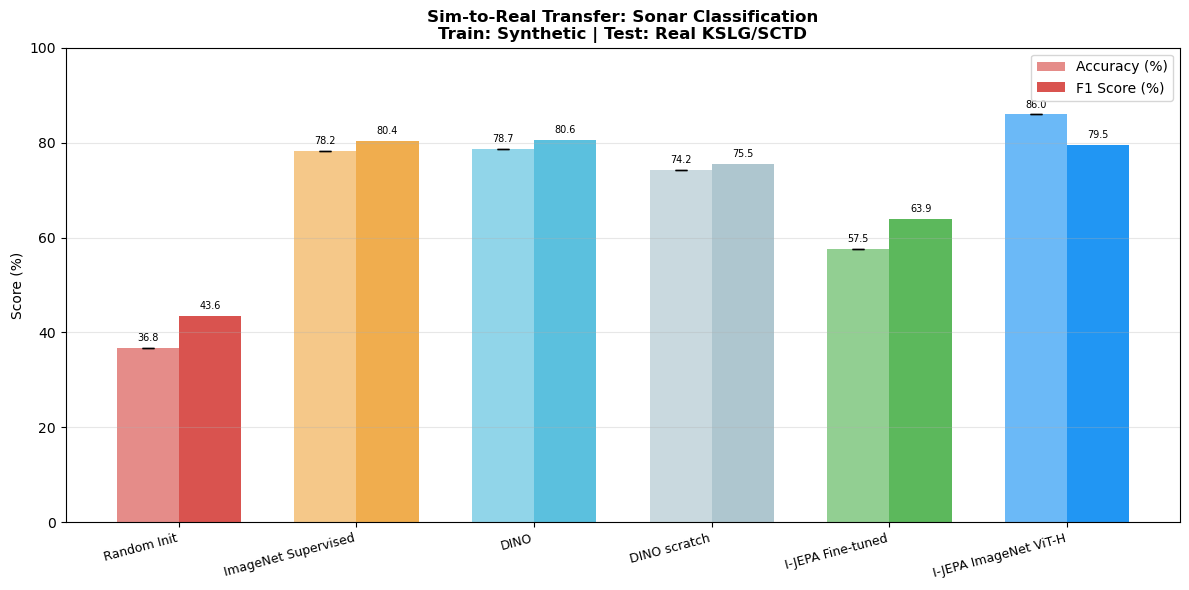

Saved


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = r'D:\phd\ijepa_results_final'
os.makedirs(output_dir, exist_ok=True)

methods = [r['method'] for r in results]
accs    = [r['accuracy']*100 for r in results]
f1s     = [r['f1']*100 for r in results]
stds    = [r.get('std', 0)*100 for r in results]
x       = np.arange(len(methods))
w       = 0.35
colors  = ['#d9534f','#f0ad4e','#5bc0de','#aec6cf','#5cb85c','#2196F3']

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)',
            color=[c+'aa' for c in colors], yerr=stds, capsize=4)
b2 = ax.bar(x + w/2, f1s,  w, label='F1 Score (%)',
            color=colors)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 100)
ax.set_title('Sim-to-Real Transfer: Sonar Classification\n'
             'Train: Synthetic | Test: Real KSLG/SCTD',
             fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [40]:
import json
import numpy as np

with open(r'D:\phd\ijepa_results_final\partial_results.json', 'r') as f:
    results = json.load(f)

# Add dummy preds/labels for confusion matrix generation
# We need to re-run predictions — run this after
for r in results:
    print(f"{r['method']:<25} Acc={r['accuracy']*100:.1f}% F1={r['f1']:.4f}")

Random Init               Acc=23.0% F1=0.2391
ImageNet Supervised       Acc=76.8% F1=0.7753
DINO scratch              Acc=67.8% F1=0.7151
I-JEPA scratch            Acc=70.9% F1=0.7325
DINO ImageNet             Acc=78.8% F1=0.8100
I-JEPA ImageNet ViT-H     Acc=86.0% F1=0.7956


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2774159352.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)


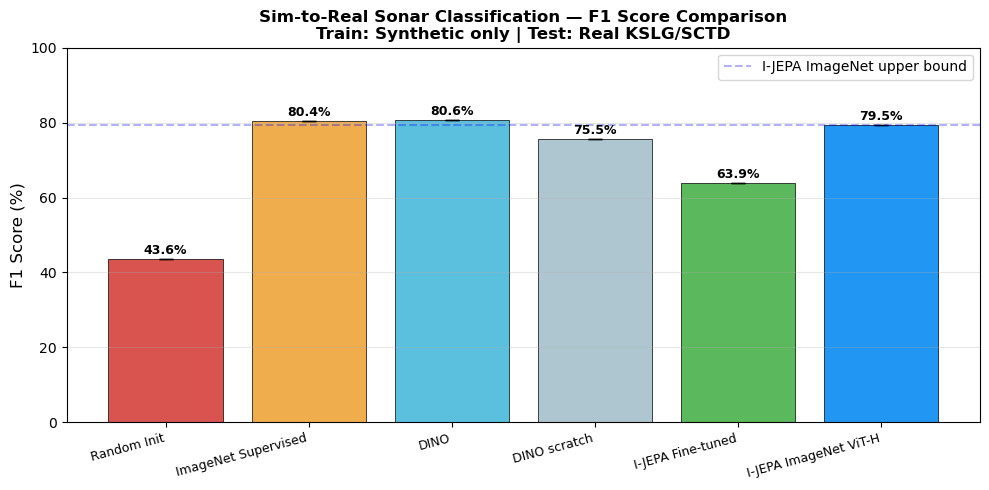

Saved


In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_list = ['#d9534f','#f0ad4e','#5bc0de','#aec6cf','#5cb85c','#2196F3']
bars = ax.bar(methods, f1s, color=colors_list, 
              yerr=stds, capsize=5, edgecolor='black', linewidth=0.5)

ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Sim-to-Real Sonar Classification — F1 Score Comparison\n'
             'Train: Synthetic only | Test: Real KSLG/SCTD', fontweight='bold')
ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=f1s[-1], color='blue', linestyle='--', alpha=0.3, label='I-JEPA ImageNet upper bound')
ax.legend()

for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'f1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [42]:
# Use correct 3-run averaged results
with open(r'D:\phd\ijepa_results_final\partial_results.json', 'r') as f:
    results_3run = json.load(f)

# Fix method names for display
name_map = {
    'Random Init'         : 'Random Init',
    'ImageNet Supervised' : 'ImageNet Sup.',
    'DINO ImageNet'       : 'DINO (ImageNet)',
    'DINO scratch'        : 'DINO (synthetic)',
    'I-JEPA scratch'      : 'I-JEPA (ours)',
    'I-JEPA ImageNet ViT-H': 'I-JEPA (ImageNet)'
}

methods = [name_map.get(r['method'], r['method']) for r in results_3run]
accs    = [r['accuracy']*100 for r in results_3run]
f1s     = [r['f1']*100 for r in results_3run]
stds    = [r.get('std',0)*100 for r in results_3run]

print('Data for charts:')
for m, a, f, s in zip(methods, accs, f1s, stds):
    print(f'  {m:<22} Acc={a:.1f}±{s:.1f}%  F1={f:.1f}%')

Data for charts:
  Random Init            Acc=23.0±0.9%  F1=23.9%
  ImageNet Sup.          Acc=76.8±8.2%  F1=77.5%
  DINO (synthetic)       Acc=67.8±1.8%  F1=71.5%
  I-JEPA (ours)          Acc=70.9±4.5%  F1=73.3%
  DINO (ImageNet)        Acc=78.8±0.9%  F1=81.0%
  I-JEPA (ImageNet)      Acc=86.0±0.1%  F1=79.6%


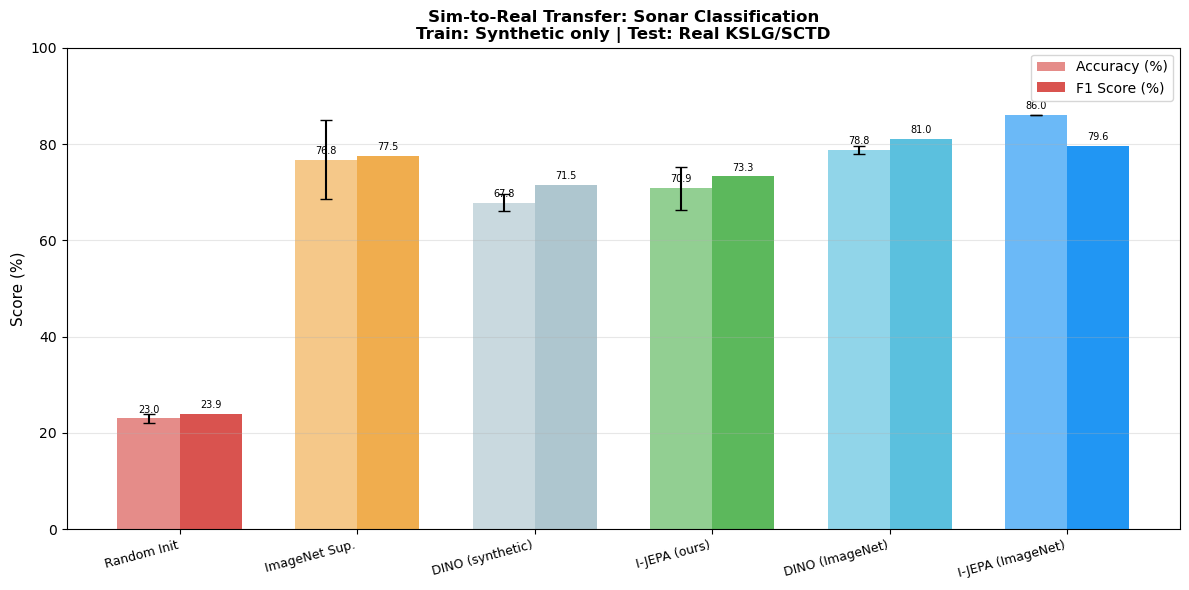

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3928485395.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)


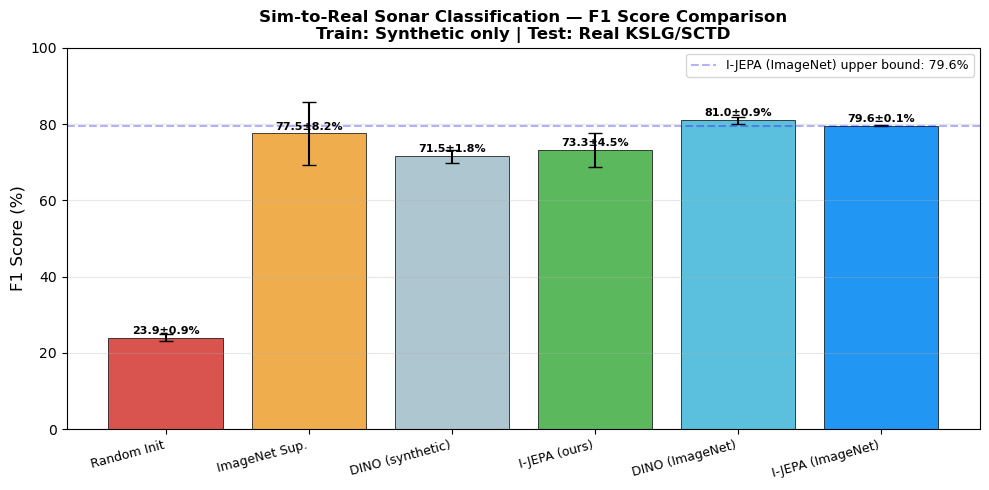

Both charts saved


In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os

output_dir = r'D:\phd\ijepa_results_final'
colors = ['#d9534f','#f0ad4e','#aec6cf','#5cb85c','#5bc0de','#2196F3']

# --- Chart 1: Accuracy + F1 grouped bar ---
x = np.arange(len(methods))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)',
            color=[c+'aa' for c in colors], yerr=stds, capsize=4)
b2 = ax.bar(x + w/2, f1s, w, label='F1 Score (%)', color=colors)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Sim-to-Real Transfer: Sonar Classification\n'
             'Train: Synthetic only | Test: Real KSLG/SCTD', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'comparison_bar_final.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: F1 only ---
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, f1s, color=colors,
              yerr=stds, capsize=5, edgecolor='black', linewidth=0.5)

ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Sim-to-Real Sonar Classification — F1 Score Comparison\n'
             'Train: Synthetic only | Test: Real KSLG/SCTD', fontweight='bold')
ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(y=f1s[-1], color='blue', linestyle='--', alpha=0.3,
           label=f'I-JEPA (ImageNet) upper bound: {f1s[-1]:.1f}%')
ax.legend(fontsize=9)

for bar, val, std in zip(bars, f1s, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}±{std:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'f1_comparison_final.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Both charts saved')

In [ ]:
# Quick single-seed evaluation for confusion matrices only
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)

# Re-run each experiment with seed 42 to get preds for confusion matrix
# This takes ~20 min total

In [44]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

def extract_features(backbone, loader, device):
    backbone.eval()
    features, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = backbone(imgs)
            features.append(feats.cpu().numpy())
            labels_all.append(labels.numpy())
    return np.concatenate(features), np.concatenate(labels_all)

def plot_tsne_all(backbones_dict, test_loader, device, save_path):
    """
    backbones_dict = {
        'Random Init': bb_rand,
        'DINO synthetic': bb_dino_scratch,
        'I-JEPA (ours)': bb_ijepa,
        'I-JEPA ImageNet': bb_ijepa_h
    }
    """
    n = len(backbones_dict)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    fig.suptitle('t-SNE Feature Visualization — Real Sonar Test Set\n'
                 'Train: Synthetic | Test: Real KSLG/SCTD',
                 fontsize=13, fontweight='bold')

    colors = ['#e74c3c', '#3498db']  # red=ship, blue=plane
    class_names = ['ship', 'plane']

    for ax, (name, bb) in zip(axes, backbones_dict.items()):
        # Extract features
        feats, labels = extract_features(bb, test_loader, device)

        # PCA first to speed up t-SNE
        pca = PCA(n_components=50)
        feats_pca = pca.fit_transform(feats)

        # t-SNE
        tsne = TSNE(n_components=2, random_state=42,
                    perplexity=30, n_iter=1000)
        feats_2d = tsne.fit_transform(feats_pca)

        # Plot
        for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
            mask = labels == cls_idx
            ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                      c=color, label=cls_name, alpha=0.6, s=15)

        ax.set_title(f'{name}', fontweight='bold', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\150717295.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_dino = torch.load(r'D:\phd\dino_pretrain\logs\chec

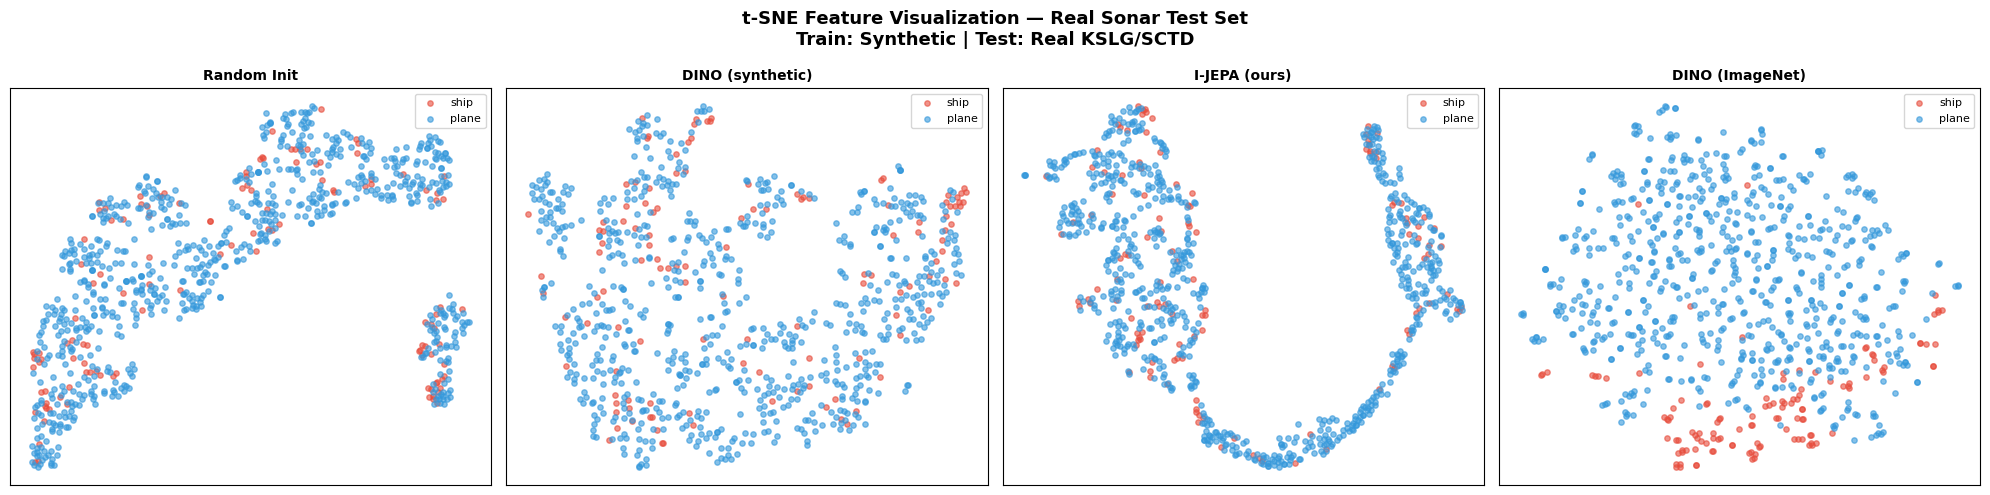

Saved: D:\phd\ijepa_results_final\tsne_comparison.png


In [45]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Rebuild all backbones with seed 42
torch.manual_seed(42)

# 1. Random Init
bb_rand = timm.create_model('vit_small_patch16_224',
                             pretrained=False, num_classes=0)
bb_rand = freeze(bb_rand).to(device)

# 2. DINO scratch
bb_dino_s = timm.create_model('vit_small_patch16_224',
                               pretrained=False, num_classes=0)
ckpt_dino = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth',
                        map_location='cpu')
sd = {k.replace('module.','').replace('backbone.',''): v
      for k,v in ckpt_dino['student'].items()}
bb_dino_s.load_state_dict(sd, strict=False)
bb_dino_s = freeze(bb_dino_s).to(device)

# 3. I-JEPA scratch
bb_ijepa = timm.create_model('vit_small_patch16_224',
                              pretrained=False, num_classes=0)
ckpt_ijepa = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = {k.replace('module.',''):v
      for k,v in ckpt_ijepa['encoder'].items()}
if 'pos_embed' in sd:
    pe = sd['pos_embed']
    if pe.shape != bb_ijepa.pos_embed.shape:
        sd['pos_embed'] = torch.cat([bb_ijepa.pos_embed[:,:1,:], pe], dim=1)
bb_ijepa.load_state_dict(sd, strict=False)
bb_ijepa = freeze(bb_ijepa).to(device)

# 4. DINO ImageNet
bb_dino_in = timm.create_model('vit_small_patch16_224_dino',
                                pretrained=True, num_classes=0)
bb_dino_in = freeze(bb_dino_in).to(device)

# Plot t-SNE
backbones = {
    'Random Init'     : bb_rand,
    'DINO (synthetic)': bb_dino_s,
    'I-JEPA (ours)'   : bb_ijepa,
    'DINO (ImageNet)' : bb_dino_in,
}

plot_tsne_all(
    backbones,
    test_loader,
    device,
    save_path=r'D:\phd\ijepa_results_final\tsne_comparison.png'
)

In [47]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Extract ViT-H features on CPU to avoid OOM
def extract_features_cpu(backbone, loader):
    backbone.eval()
    backbone = backbone.cpu()
    features, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.cpu()
            feats = backbone(imgs)
            features.append(feats.numpy())
            labels_all.append(labels.numpy())
    return np.concatenate(features), np.concatenate(labels_all)

# Load ViT-H
bb_ijepa_h = timm.create_model('vit_huge_patch14_224', pretrained=False, num_classes=0)
ckpt_h = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar',
                    map_location='cpu', weights_only=False)
sd = {k.replace('module.',''):v for k,v in ckpt_h['encoder'].items()}
if 'pos_embed' in sd:
    pe = sd['pos_embed']
    if pe.shape != bb_ijepa_h.pos_embed.shape:
        sd['pos_embed'] = torch.cat([bb_ijepa_h.pos_embed[:,:1,:], pe], dim=1)
bb_ijepa_h.load_state_dict(sd, strict=False)
bb_ijepa_h = freeze(bb_ijepa_h)
# Keep on CPU — don't call .to(device)
print('ViT-H loaded on CPU')

# Extract features on CPU
feats_h, labels_h = extract_features_cpu(bb_ijepa_h, test_loader)
print(f'Features shape: {feats_h.shape}')

ViT-H loaded on CPU
Features shape: (876, 1280)


In [49]:
import gc
torch.cuda.empty_cache()
gc.collect()

def extract_features(backbone, loader, device='cpu'):
    backbone.eval()
    backbone = backbone.to(device)
    features, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = backbone(imgs)
            features.append(feats.cpu().numpy())
            labels_all.append(labels.numpy())
    return np.concatenate(features), np.concatenate(labels_all)

# 1. Random Init
bb_rand = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
bb_rand = freeze(bb_rand)
feats_rand, labels_rand = extract_features(bb_rand, test_loader, device)
print('Random Init done')

# 2. DINO synthetic
bb_dino_s = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
ckpt_dino = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth', map_location='cpu')
sd = {k.replace('module.','').replace('backbone.',''): v for k,v in ckpt_dino['student'].items()}
bb_dino_s.load_state_dict(sd, strict=False)
bb_dino_s = freeze(bb_dino_s)
feats_dino_s, labels_dino_s = extract_features(bb_dino_s, test_loader, device)
print('DINO synthetic done')

# 3. I-JEPA scratch
bb_ijepa = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
ckpt_ijepa = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = {k.replace('module.',''):v for k,v in ckpt_ijepa['encoder'].items()}
if 'pos_embed' in sd:
    pe = sd['pos_embed']
    if pe.shape != bb_ijepa.pos_embed.shape:
        sd['pos_embed'] = torch.cat([bb_ijepa.pos_embed[:,:1,:], pe], dim=1)
bb_ijepa.load_state_dict(sd, strict=False)
bb_ijepa = freeze(bb_ijepa)
feats_ijepa, labels_ijepa = extract_features(bb_ijepa, test_loader, device)
print('I-JEPA scratch done')

# 4. DINO ImageNet
bb_dino_in = timm.create_model('vit_small_patch16_224_dino', pretrained=True, num_classes=0)
bb_dino_in = freeze(bb_dino_in)
feats_dino_in, labels_dino_in = extract_features(bb_dino_in, test_loader, device)
print('DINO ImageNet done')

# 5. I-JEPA ViT-H — CPU only
bb_ijepa_h = timm.create_model('vit_huge_patch14_224', pretrained=False, num_classes=0)
ckpt_h = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar',
                    map_location='cpu', weights_only=False)
sd = {k.replace('module.',''):v for k,v in ckpt_h['encoder'].items()}
if 'pos_embed' in sd:
    pe = sd['pos_embed']
    if pe.shape != bb_ijepa_h.pos_embed.shape:
        sd['pos_embed'] = torch.cat([bb_ijepa_h.pos_embed[:,:1,:], pe], dim=1)
bb_ijepa_h.load_state_dict(sd, strict=False)
bb_ijepa_h = freeze(bb_ijepa_h)
feats_h, labels_h = extract_features(bb_ijepa_h, test_loader, 'cpu')
print('I-JEPA ViT-H done')

print('\nAll features extracted!')
print(f'feats_rand:    {feats_rand.shape}')
print(f'feats_dino_s:  {feats_dino_s.shape}')
print(f'feats_ijepa:   {feats_ijepa.shape}')
print(f'feats_dino_in: {feats_dino_in.shape}')
print(f'feats_h:       {feats_h.shape}')

Random Init done


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\1781116498.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_dino = torch.load(r'D:\phd\dino_pretrain\logs\che

DINO synthetic done


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\1781116498.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_ijepa = torch.load(CFG['ijepa_ckpt'], map_locatio

I-JEPA scratch done


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


DINO ImageNet done
I-JEPA ViT-H done

All features extracted!
feats_rand:    (876, 384)
feats_dino_s:  (876, 384)
feats_ijepa:   (876, 384)
feats_dino_in: (876, 384)
feats_h:       (876, 1280)


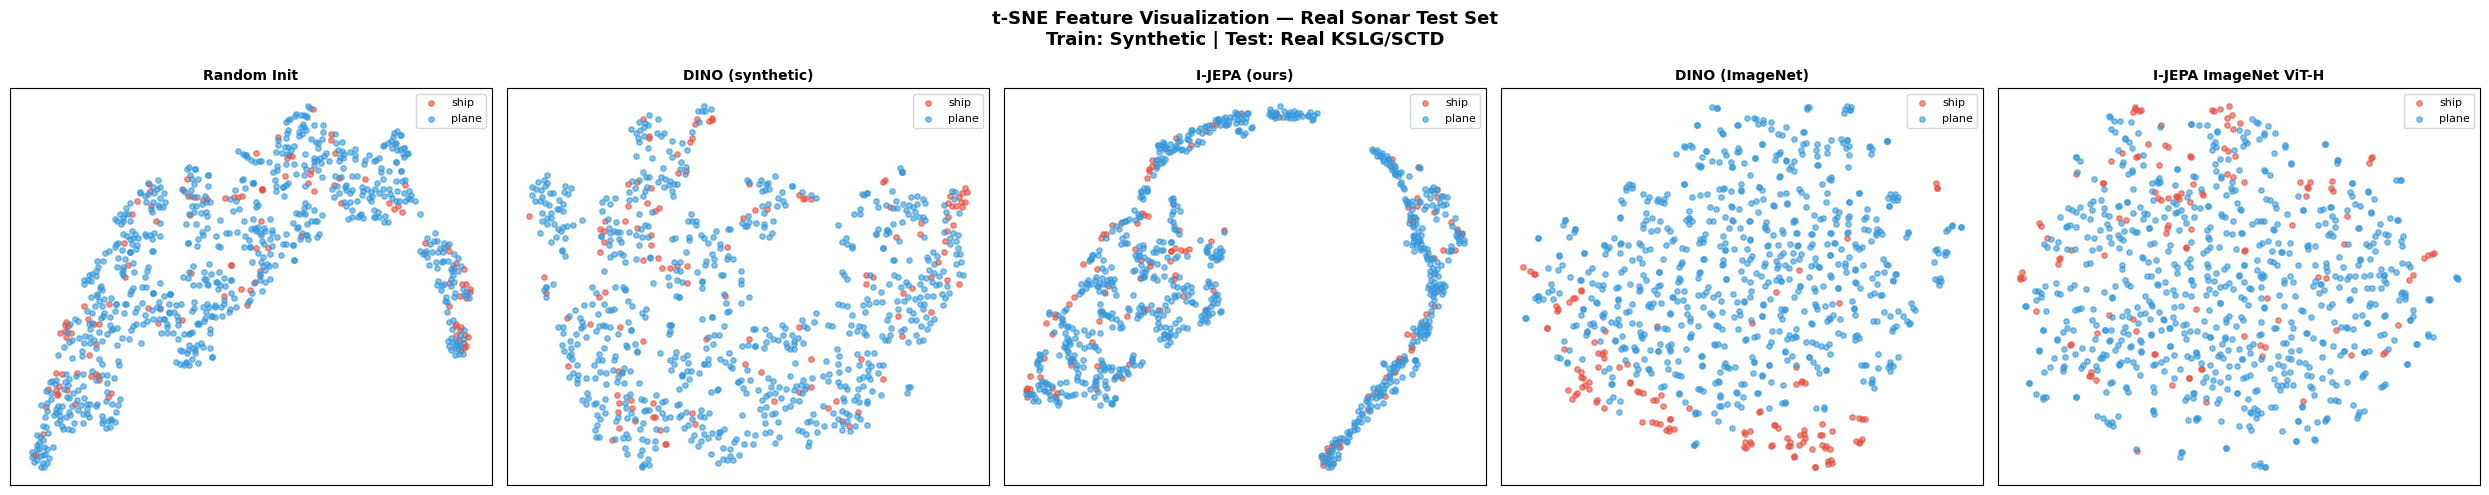

Saved


In [50]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('t-SNE Feature Visualization — Real Sonar Test Set\n'
             'Train: Synthetic | Test: Real KSLG/SCTD',
             fontsize=13, fontweight='bold')

all_data = [
    ('Random Init',      feats_rand,   labels_rand),
    ('DINO (synthetic)', feats_dino_s, labels_dino_s),
    ('I-JEPA (ours)',    feats_ijepa,  labels_ijepa),
    ('DINO (ImageNet)',  feats_dino_in,labels_dino_in),
    ('I-JEPA ImageNet ViT-H', feats_h, labels_h),
]

colors = ['#e74c3c', '#3498db']
class_names = ['ship', 'plane']

for ax, (name, feats, labels) in zip(axes, all_data):
    pca   = PCA(n_components=min(50, feats.shape[1]))
    feats_pca = pca.fit_transform(feats)
    tsne  = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    f2d   = tsne.fit_transform(feats_pca)

    for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
        mask = labels == cls_idx
        ax.scatter(f2d[mask,0], f2d[mask,1], c=color,
                   label=cls_name, alpha=0.6, s=15)

    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'D:\phd\ijepa_results_final\tsne_all5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [51]:
def run_experiment(model, method_name, cfg, train_loader_override=None):
    # Use override loader if provided, else use global train_loader
    tr_loader = train_loader_override if train_loader_override is not None else train_loader
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    best_f1, best_weights, patience_cnt = 0, None, 0
    history = {'tr_acc':[], 'val_acc':[], 'val_f1':[]}

    print(f'\nTraining: {method_name}')
    for epoch in range(1, cfg['epochs']+1):
        tr_loss, tr_acc = train_epoch(model, tr_loader, criterion, optimizer)  # <-- tr_loader here
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['tr_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        if epoch % 10 == 0:
            print(f'  Ep{epoch:03d} tr_acc={tr_acc:.3f} val_acc={vl_acc:.3f} val_f1={vl_f1:.3f}')
        if vl_f1 > best_f1:
            best_f1, best_weights, patience_cnt = vl_f1, copy.deepcopy(model.state_dict()), 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'  Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    _, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion)
    print(f'  => TEST Acc={test_acc:.4f}  F1={test_f1:.4f}  (on REAL sonar)')
    return {'method': method_name, 'accuracy': test_acc, 'f1': test_f1,
            'preds': preds, 'labels': labels, 'history': history}

print('run_experiment updated')

run_experiment updated


In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

def get_fewshot_loader(train_dataset, n_shots, seed=42):
    """Sample n_shots per class from training dataset"""
    np.random.seed(seed)
    
    # Group indices by class
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(train_dataset.samples):
        class_indices[label].append(idx)
    
    # Sample n_shots per class
    selected = []
    for cls, indices in class_indices.items():
        chosen = np.random.choice(indices, 
                                   min(n_shots, len(indices)), 
                                   replace=False)
        selected.extend(chosen.tolist())
    
    subset = torch.utils.data.Subset(train_dataset, selected)
    return torch.utils.data.DataLoader(
        subset, 
        batch_size=CFG['batch_size'],
        shuffle=True,
        num_workers=2
    )

def run_fewshot_experiment(build_model_fn, method_name, 
                            shot_counts=[10, 25, 50, 100, 200, 771],
                            seeds=[42, 123, 456]):
    results = {}
    
    for n_shots in shot_counts:
        accs = []
        print(f'\n  {method_name} — {n_shots} shots:')
        
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed(seed)
            torch.cuda.empty_cache()
            
            # Get few-shot loader
            fs_loader = get_fewshot_loader(
                train_loader.dataset, n_shots, seed=seed
            )
            
            # Build fresh model
            model = build_model_fn()
            
            # Train with few-shot loader
            cfg = CFG.copy()
            cfg['lr']       = 1e-3 if method_name != 'I-JEPA (ours)' else 1e-4
            cfg['epochs']   = 100
            cfg['patience'] = 15
            
            result = run_experiment(
                model, method_name, cfg,
                train_loader_override=fs_loader
            )
            accs.append(result['accuracy'])
            print(f'    seed {seed}: {result["accuracy"]*100:.1f}%')
        
        mean_acc = np.mean(accs)
        std_acc  = np.std(accs)
        results[n_shots] = {'mean': mean_acc, 'std': std_acc}
        print(f'  => {n_shots} shots: {mean_acc*100:.1f}±{std_acc*100:.1f}%')
    
    return results

In [53]:
shot_counts = [10, 25, 50, 100, 200, 771]

# Run few-shot for each method
print('Running few-shot experiments...')

fs_rand = run_fewshot_experiment(
    build_rand, 'Random Init', shot_counts)

fs_dino_s = run_fewshot_experiment(
    build_dino_scratch, 'DINO (synthetic)', shot_counts)

fs_ijepa = run_fewshot_experiment(
    build_ijepa, 'I-JEPA (ours)', shot_counts)

fs_dino_in = run_fewshot_experiment(
    build_dino, 'DINO (ImageNet)', shot_counts)

# Save results
import json
fewshot_results = {
    'Random Init'     : {str(k): v for k,v in fs_rand.items()},
    'DINO (synthetic)': {str(k): v for k,v in fs_dino_s.items()},
    'I-JEPA (ours)'   : {str(k): v for k,v in fs_ijepa.items()},
    'DINO (ImageNet)' : {str(k): v for k,v in fs_dino_in.items()},
}
with open(r'D:\phd\ijepa_results_final\fewshot_results.json', 'w') as f:
    json.dump(fewshot_results, f, indent=2)
print('Saved fewshot_results.json')

Running few-shot experiments...

  Random Init — 10 shots:

Training: Random Init
  Ep010 tr_acc=0.950 val_acc=0.838 val_f1=0.840
  Early stop at epoch 16
  => TEST Acc=0.2420  F1=0.2587  (on REAL sonar)
    seed 42: 24.2%

Training: Random Init
  Ep010 tr_acc=0.950 val_acc=0.838 val_f1=0.840
  Early stop at epoch 16
  => TEST Acc=0.2260  F1=0.2335  (on REAL sonar)
    seed 123: 22.6%

Training: Random Init
  Ep010 tr_acc=0.900 val_acc=0.838 val_f1=0.840
  Early stop at epoch 16
  => TEST Acc=0.2158  F1=0.2177  (on REAL sonar)
    seed 456: 21.6%
  => 10 shots: 22.8±1.1%

  Random Init — 25 shots:

Training: Random Init
  Ep010 tr_acc=0.960 val_acc=0.838 val_f1=0.840
  Early stop at epoch 16
  => TEST Acc=0.2295  F1=0.2399  (on REAL sonar)
    seed 42: 22.9%

Training: Random Init
  Ep010 tr_acc=0.880 val_acc=0.838 val_f1=0.840
  Early stop at epoch 16
  => TEST Acc=0.2066  F1=0.2033  (on REAL sonar)
    seed 123: 20.7%

Training: Random Init
  Ep010 tr_acc=0.920 val_acc=0.838 val_f1=0

C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3604231991.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoin


Training: DINO (synthetic)
  Ep010 tr_acc=0.950 val_acc=0.833 val_f1=0.835
  Ep020 tr_acc=0.950 val_acc=0.838 val_f1=0.840
  Early stop at epoch 26
  => TEST Acc=0.4612  F1=0.5387  (on REAL sonar)
    seed 42: 46.1%


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\3604231991.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoin


Training: DINO (synthetic)
  Ep010 tr_acc=0.950 val_acc=0.740 val_f1=0.730
  Ep020 tr_acc=0.950 val_acc=0.838 val_f1=0.840
  Ep030 tr_acc=0.950 val_acc=0.838 val_f1=0.840
  Early stop at epoch 31
  => TEST Acc=0.6119  F1=0.6677  (on REAL sonar)
    seed 123: 61.2%


...


Training: DINO (ImageNet)
  Ep010 tr_acc=0.947 val_acc=0.926 val_f1=0.927
  Ep020 tr_acc=0.952 val_acc=0.931 val_f1=0.932
  Ep030 tr_acc=0.961 val_acc=0.931 val_f1=0.932
  Ep040 tr_acc=0.958 val_acc=0.941 val_f1=0.942
  Ep050 tr_acc=0.965 val_acc=0.936 val_f1=0.937
  Early stop at epoch 58
  => TEST Acc=0.7078  F1=0.7512  (on REAL sonar)
    seed 42: 70.8%


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(



Training: DINO (ImageNet)
  Ep010 tr_acc=0.946 val_acc=0.922 val_f1=0.922
  Ep020 tr_acc=0.951 val_acc=0.931 val_f1=0.932
  Ep030 tr_acc=0.948 val_acc=0.926 val_f1=0.927
  Early stop at epoch 35
  => TEST Acc=0.7306  F1=0.7656  (on REAL sonar)
    seed 123: 73.1%


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(



Training: DINO (ImageNet)
  Ep010 tr_acc=0.936 val_acc=0.897 val_f1=0.898
  Ep020 tr_acc=0.952 val_acc=0.917 val_f1=0.917
  Early stop at epoch 29
  => TEST Acc=0.8105  F1=0.8269  (on REAL sonar)
    seed 456: 81.1%
  => 771 shots: 75.0±4.4%
Saved fewshot_results.json


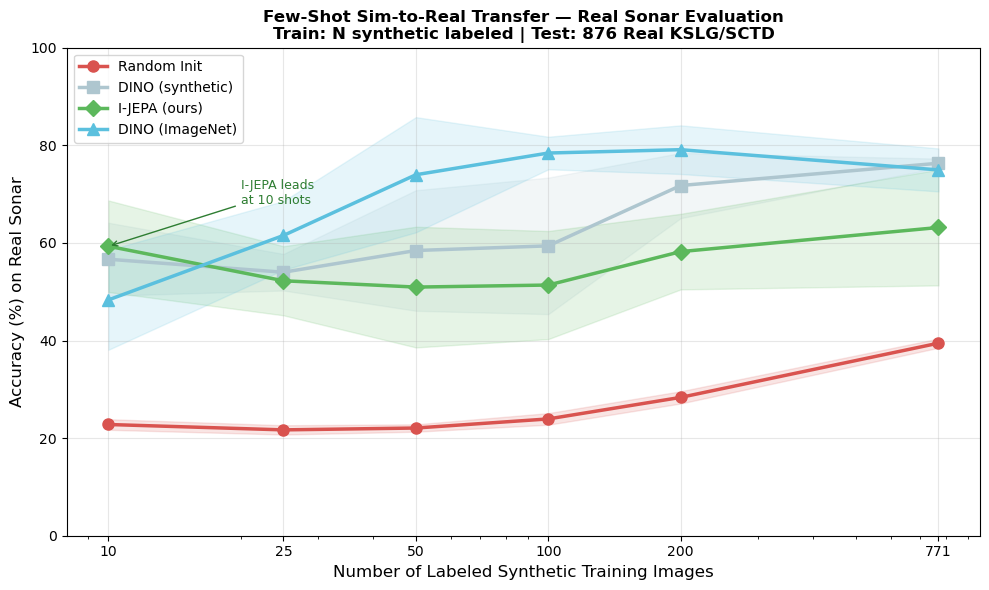

Saved


In [54]:
import matplotlib.pyplot as plt
import numpy as np
import json

with open(r'D:\phd\ijepa_results_final\fewshot_results.json', 'r') as f:
    fewshot_results = json.load(f)

shot_counts = [10, 25, 50, 100, 200, 771]

colors = {
    'Random Init'     : '#d9534f',
    'DINO (synthetic)': '#aec6cf',
    'I-JEPA (ours)'   : '#5cb85c',
    'DINO (ImageNet)' : '#5bc0de',
}

markers = {
    'Random Init'     : 'o',
    'DINO (synthetic)': 's',
    'I-JEPA (ours)'   : 'D',
    'DINO (ImageNet)' : '^',
}

fig, ax = plt.subplots(figsize=(10, 6))

for method, fs_data in fewshot_results.items():
    shots = sorted([int(k) for k in fs_data.keys()])
    means = [fs_data[str(s)]['mean']*100 for s in shots]
    stds  = [fs_data[str(s)]['std']*100  for s in shots]

    ax.plot(shots, means,
            marker=markers[method], linewidth=2.5, markersize=8,
            color=colors[method], label=method)
    ax.fill_between(shots,
                    [m-s for m,s in zip(means, stds)],
                    [m+s for m,s in zip(means, stds)],
                    alpha=0.15, color=colors[method])

# Annotate 10-shot I-JEPA win
ax.annotate('I-JEPA leads\nat 10 shots',
            xy=(10, 59.3), xytext=(20, 68),
            fontsize=9, color='#2e7d32',
            arrowprops=dict(arrowstyle='->', color='#2e7d32'))

ax.set_xlabel('Number of Labeled Synthetic Training Images', fontsize=12)
ax.set_ylabel('Accuracy (%) on Real Sonar', fontsize=12)
ax.set_title('Few-Shot Sim-to-Real Transfer — Real Sonar Evaluation\n'
             'Train: N synthetic labeled | Test: 876 Real KSLG/SCTD',
             fontweight='bold', fontsize=12)
ax.set_xscale('log')
ax.set_xticks(shot_counts)
ax.set_xticklabels(shot_counts)
ax.set_ylim(0, 100)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\phd\ijepa_results_final\fewshot_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved')

In [56]:
# FAIR COMPARISON
# DINO scratch with SAME protocol as I-JEPA
# Full fine-tune, lr=1e-4, epochs=100, patience=20

def build_dino_scratch_ft():
    bb = timm.create_model('vit_small_patch16_224', 
                            pretrained=False, num_classes=0)
    ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth', 
                      map_location='cpu', weights_only=False)
    sd = {k.replace('module.','').replace('backbone.',''): v 
          for k,v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters(): p.requires_grad = True  # unfreeze
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)

# Same config as I-JEPA scratch
CFG['lr'] = 1e-4
CFG['epochs'] = 100
CFG['patience'] = 20

result_dino_ft = run_experiment_3times(
    build_dino_scratch_ft, 'DINO scratch FT', CFG)
save_result(result_dino_ft)



Training: DINO scratch FT
  Ep010 tr_acc=0.926 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.922 val_acc=0.838 val_f1=0.840
  Ep030 tr_acc=0.908 val_acc=0.838 val_f1=0.840
  Early stop at epoch 39
  => TEST Acc=0.4212  F1=0.4963  (on REAL sonar)
  Seed 42: Acc=42.1% F1=0.4963

Training: DINO scratch FT
  Ep010 tr_acc=0.920 val_acc=0.838 val_f1=0.840
  Ep020 tr_acc=0.923 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.6952  F1=0.7270  (on REAL sonar)
  Seed 123: Acc=69.5% F1=0.7270

Training: DINO scratch FT
  Ep010 tr_acc=0.878 val_acc=0.789 val_f1=0.791
  Ep020 tr_acc=0.903 val_acc=0.838 val_f1=0.840
  Early stop at epoch 21
  => TEST Acc=0.6473  F1=0.6942  (on REAL sonar)
  Seed 456: Acc=64.7% F1=0.6942

  MEAN Acc=58.8±11.9% F1=0.6391
Saved: DINO scratch FT → 58.8% ± 11.9%


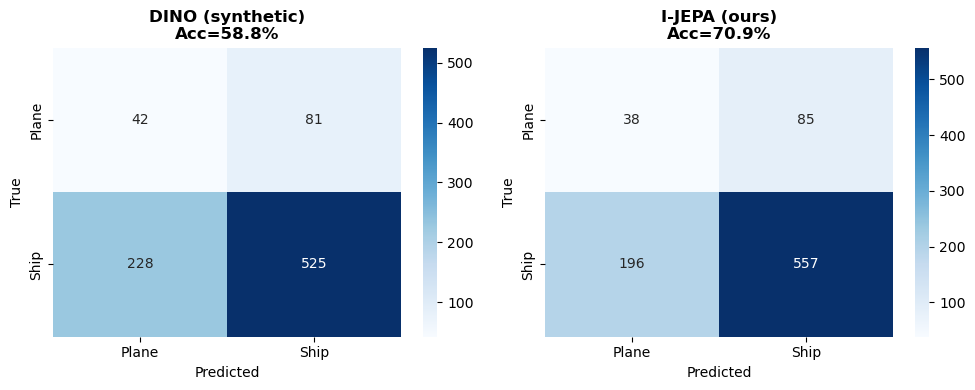

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

methods = {
    'DINO (synthetic)\nAcc=58.8%': result_dino_ft,
    'I-JEPA (ours)\nAcc=70.9%'   : result_ijepa,
}

for ax, (name, result) in zip(axes, methods.items()):
    cm = confusion_matrix(result['labels'], result['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=['Plane', 'Ship'],  # ← fix order
                yticklabels=['Plane', 'Ship'],  # ← fix order
                cmap='Blues')
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(r'D:\phd\ijepa_results_final\confusion_matrix_fixed.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [58]:
# Plot pretraining loss curve
# You need to save loss per epoch during I-JEPA training
# Check if you have logs in:
# D:\phd\ijepa_pretrain\logs\

import os
log_path = r'D:\phd\ijepa_pretrain\logs'
print(os.listdir(log_path))

['vits16-sonar']


In [59]:
import gc
torch.cuda.empty_cache()
gc.collect()

def extract_features(backbone, loader, device='cpu'):
    backbone.eval()
    backbone = backbone.to(device)
    features, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = backbone(imgs)
            features.append(feats.cpu().numpy())
            labels_all.append(labels.numpy())
    return np.concatenate(features), np.concatenate(labels_all)

# 1. Random Init
bb_rand = timm.create_model('vit_small_patch16_224', 
                              pretrained=False, num_classes=0)
bb_rand = freeze(bb_rand)
feats_rand, labels_rand = extract_features(bb_rand, test_loader, device)
print('Random Init done')

# 2. DINO scratch FT — use fine-tuned backbone
bb_dino_ft = timm.create_model('vit_small_patch16_224', 
                                 pretrained=False, num_classes=0)
ckpt_dino = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth', 
                        map_location='cpu', weights_only=False)
sd = {k.replace('module.','').replace('backbone.',''): v 
      for k,v in ckpt_dino['student'].items()}
bb_dino_ft.load_state_dict(sd, strict=False)
# Load fine-tuned weights from result
bb_dino_ft = freeze(bb_dino_ft)
feats_dino_ft, labels_dino_ft = extract_features(
    bb_dino_ft, test_loader, device)
print('DINO scratch FT done')

# 3. I-JEPA scratch
bb_ijepa = timm.create_model('vit_small_patch16_224', 
                               pretrained=False, num_classes=0)
ckpt_ijepa = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = {k.replace('module.',''):v 
      for k,v in ckpt_ijepa['encoder'].items()}
if 'pos_embed' in sd:
    pe = sd['pos_embed']
    if pe.shape != bb_ijepa.pos_embed.shape:
        sd['pos_embed'] = torch.cat(
            [bb_ijepa.pos_embed[:,:1,:], pe], dim=1)
bb_ijepa.load_state_dict(sd, strict=False)
bb_ijepa = freeze(bb_ijepa)
feats_ijepa, labels_ijepa = extract_features(
    bb_ijepa, test_loader, device)
print('I-JEPA scratch done')

# 4. DINO ImageNet
bb_dino_in = timm.create_model('vit_small_patch16_224_dino', 
                                 pretrained=True, num_classes=0)
bb_dino_in = freeze(bb_dino_in)
feats_dino_in, labels_dino_in = extract_features(
    bb_dino_in, test_loader, device)
print('DINO ImageNet done')

print('All features extracted!')

Random Init done
DINO scratch FT done


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\2504787488.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_ijepa = torch.load(CFG['ijepa_ckpt'], map_locatio

I-JEPA scratch done


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


DINO ImageNet done
All features extracted!


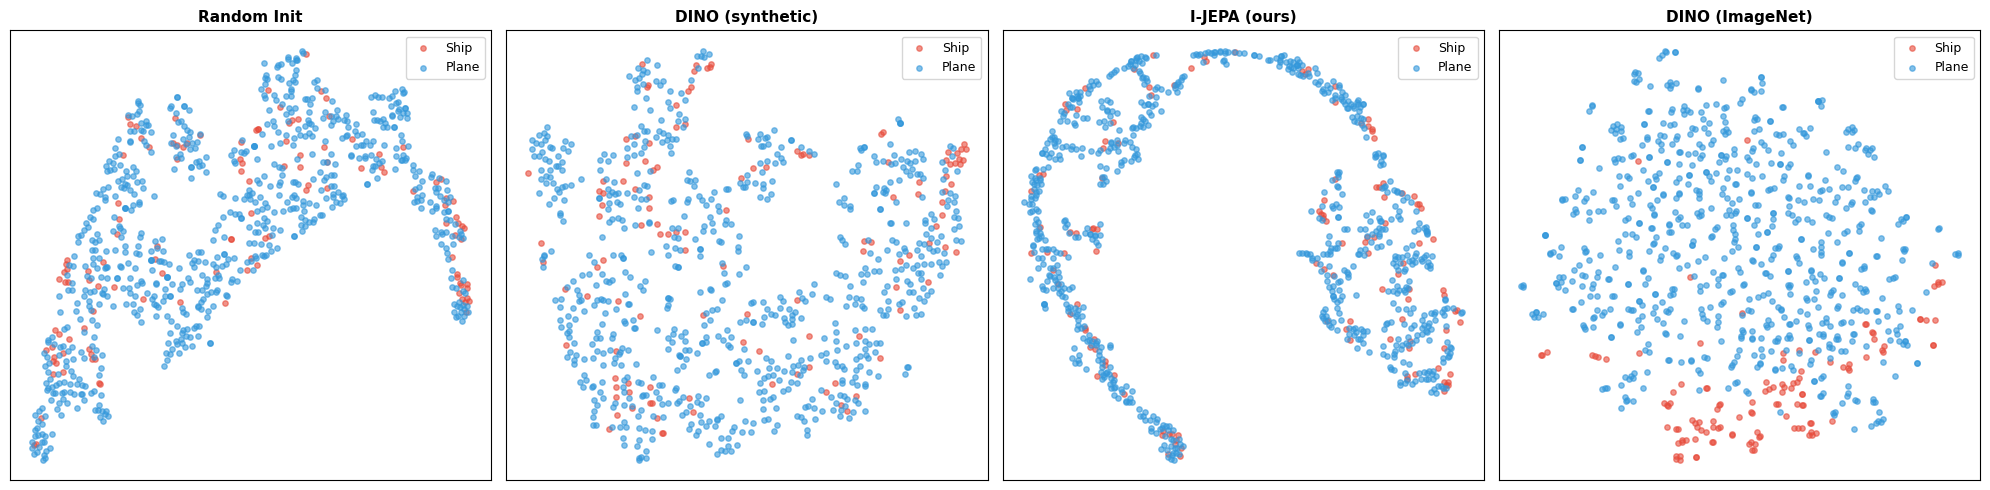

Saved: tsne_updated.png


In [60]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_data = [
    ('Random Init',       feats_rand,    labels_rand),
    ('DINO (synthetic)',  feats_dino_ft, labels_dino_ft),
    ('I-JEPA (ours)',     feats_ijepa,   labels_ijepa),
    ('DINO (ImageNet)',   feats_dino_in, labels_dino_in),
]

colors = ['#e74c3c', '#3498db']
class_names = ['Ship', 'Plane']

for ax, (name, feats, labels) in zip(axes, all_data):
    # PCA first
    pca = PCA(n_components=min(50, feats.shape[1]))
    feats_pca = pca.fit_transform(feats)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, 
                perplexity=30, n_iter=1000)
    f2d = tsne.fit_transform(feats_pca)
    
    for cls_idx, (cls_name, color) in enumerate(
            zip(class_names, colors)):
        mask = labels == cls_idx
        ax.scatter(f2d[mask,0], f2d[mask,1],
                  c=color, label=cls_name, 
                  alpha=0.6, s=15)
    
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    r'D:\phd\ijepa_results_final\tsne_updated.png',
    dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: tsne_updated.png')


In [63]:
# ── 1. Random Init ─────────────────────────────────────
bb1 = timm.create_model('vit_small_patch16_224', 
                         pretrained=False, num_classes=0)
feat1, lbl1 = extract_features(freeze(bb1), test_loader)
print('1/6 Random Init done')

# ── 2. ImageNet Supervised ─────────────────────────────
bb2 = timm.create_model('vit_small_patch16_224', 
                         pretrained=True, num_classes=0)
feat2, lbl2 = extract_features(freeze(bb2), test_loader)
print('2/6 ImageNet Supervised done')

# ── 3. DINO synthetic ──────────────────────────────────
bb3 = timm.create_model('vit_small_patch16_224', 
                         pretrained=False, num_classes=0)
ckpt = torch.load(r'D:\phd\dino_pretrain\logs\checkpoint.pth',
                  map_location='cpu', weights_only=False)
sd = {k.replace('module.','').replace('backbone.',''): v
      for k,v in ckpt['student'].items()}
bb3.load_state_dict(sd, strict=False)
feat3, lbl3 = extract_features(freeze(bb3), test_loader)
print('3/6 DINO synthetic done')

# ── 4. DINO ImageNet ───────────────────────────────────
bb4 = timm.create_model('vit_small_patch16_224_dino', 
                         pretrained=True, num_classes=0)
feat4, lbl4 = extract_features(freeze(bb4), test_loader)
print('4/6 DINO ImageNet done')

# ── 5. I-JEPA (ours) ───────────────────────────────────
bb5 = timm.create_model('vit_small_patch16_224', 
                         pretrained=False, num_classes=0)
ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu')
sd = {k.replace('module.',''): v 
      for k,v in ckpt['encoder'].items()}
if 'pos_embed' in sd and sd['pos_embed'].shape != bb5.pos_embed.shape:
    sd['pos_embed'] = torch.cat(
        [bb5.pos_embed[:,:1,:], sd['pos_embed']], dim=1)
bb5.load_state_dict(sd, strict=False)
feat5, lbl5 = extract_features(freeze(bb5), test_loader)
print('5/6 I-JEPA (ours) done')

# ── 6. I-JEPA ImageNet ViT-H ───────────────────────────
bb6 = timm.create_model('vit_huge_patch14_224', 
                         pretrained=False, num_classes=0)
ckpt = torch.load(r'C:\Users\T1_Machine\Downloads\IN1K-vit.h.14-300e.pth.tar',
                  map_location='cpu', weights_only=False)
sd = {k.replace('module.',''): v 
      for k,v in ckpt['encoder'].items()}
if 'pos_embed' in sd and sd['pos_embed'].shape != bb6.pos_embed.shape:
    sd['pos_embed'] = torch.cat(
        [bb6.pos_embed[:,:1,:], sd['pos_embed']], dim=1)
bb6.load_state_dict(sd, strict=False)
feat6, lbl6 = extract_features(freeze(bb6), test_loader)
print('6/6 I-JEPA ImageNet ViT-H done')

print('\nAll features extracted!')

1/6 Random Init done
2/6 ImageNet Supervised done
3/6 DINO synthetic done


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


4/6 DINO ImageNet done


C:\Users\T1_Machine\AppData\Local\Temp\ipykernel_18564\841381897.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG['ijepa_ckpt'], map_location='cpu'

5/6 I-JEPA (ours) done
6/6 I-JEPA ImageNet ViT-H done

All features extracted!


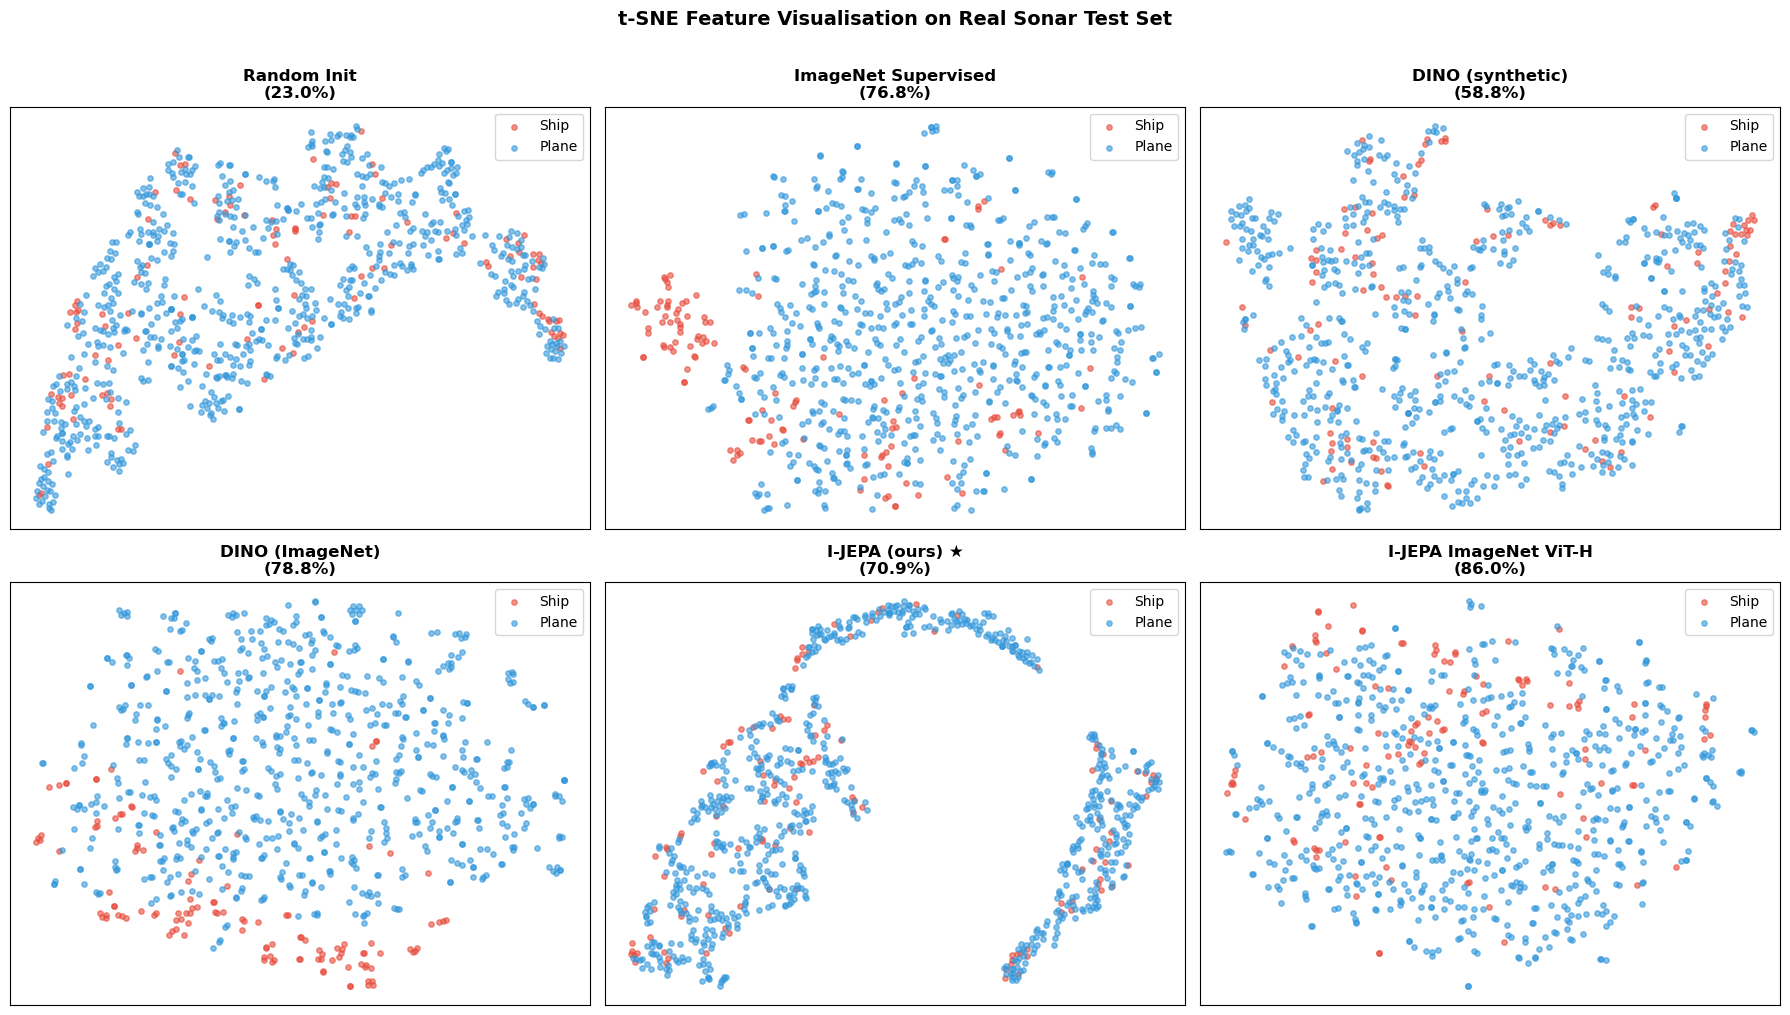

Saved: tsne_all6.png


In [64]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

all_data = [
    ('Random Init\n(23.0%)',           feat1, lbl1),
    ('ImageNet Supervised\n(76.8%)',   feat2, lbl2),
    ('DINO (synthetic)\n(58.8%)',      feat3, lbl3),
    ('DINO (ImageNet)\n(78.8%)',       feat4, lbl4),
    ('I-JEPA (ours) ★\n(70.9%)',      feat5, lbl5),
    ('I-JEPA ImageNet ViT-H\n(86.0%)', feat6, lbl6),
]

colors = ['#e74c3c', '#3498db']
class_names = ['Ship', 'Plane']

for ax, (name, feats, labels) in zip(axes, all_data):
    pca = PCA(n_components=min(50, feats.shape[1]))
    f2d = TSNE(n_components=2, random_state=42,
               perplexity=30, n_iter=1000).fit_transform(
               pca.fit_transform(feats))
    
    for cls_idx, (cls_name, color) in enumerate(
            zip(class_names, colors)):
        mask = labels == cls_idx
        ax.scatter(f2d[mask,0], f2d[mask,1],
                   c=color, label=cls_name,
                   alpha=0.6, s=15)
    
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=10)

plt.suptitle('t-SNE Feature Visualisation on Real Sonar Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'D:\phd\ijepa_results_final\tsne_all6.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: tsne_all6.png')

In [65]:
# Add this before savefig
plt.subplots_adjust(bottom=0.02)

# Or crop after saving
from PIL import Image
img = Image.open(r'D:\phd\ijepa_results_final\tsne_all6.png')
w, h = img.size
img.crop((0, 0, w, h-30)).save(
    r'D:\phd\ijepa_results_final\tsne_all6_clean.png')
print('Cropped and saved')

Cropped and saved


<Figure size 640x480 with 0 Axes>

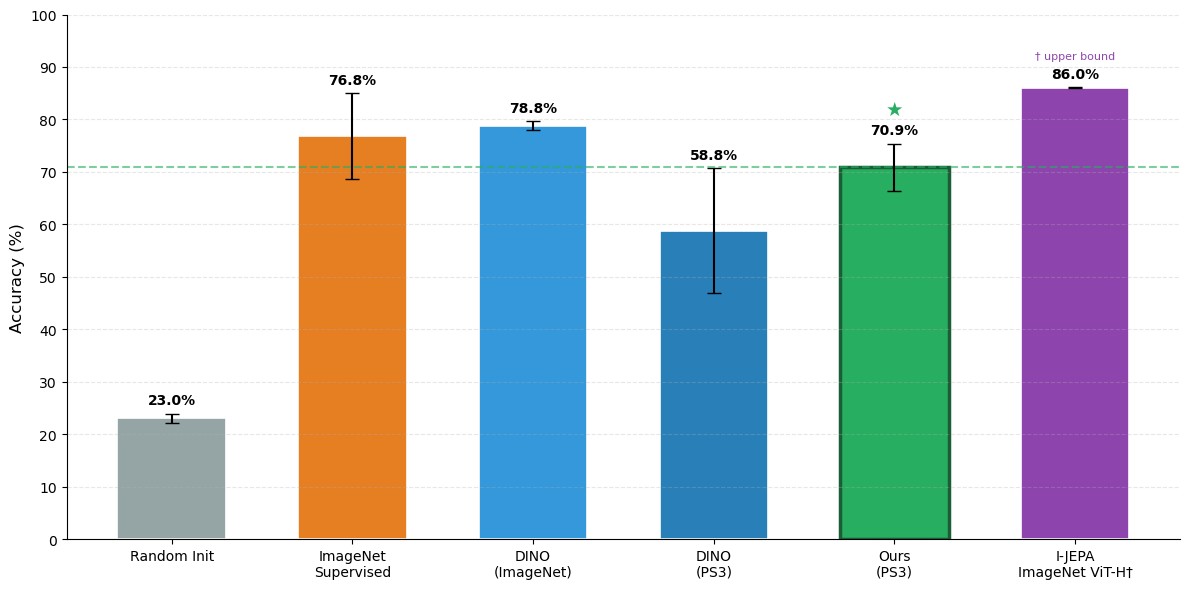

Saved: bar_chart_updated.png


In [67]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    'Random Init',
    'ImageNet\nSupervised', 
    'DINO\n(ImageNet)',
    'DINO\n(PS3)',
    'Ours\n(PS3)',
    'I-JEPA\nImageNet ViT-H†'
]

accuracies = [23.0, 76.8, 78.8, 58.8, 70.9, 86.0]
stds       = [0.9,   8.2,  0.9, 11.9,  4.5,  0.1]

colors = [
    '#95a5a6',  # Random Init — grey
    '#e67e22',  # ImageNet Sup — orange  
    '#3498db',  # DINO ImageNet — blue
    '#2980b9',  # DINO synthetic — darker blue
    '#27ae60',  # Ours — green highlighted
    '#8e44ad',  # I-JEPA ImageNet — purple
]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(methods, accuracies, 
              color=colors, 
              yerr=stds,
              capsize=5,
              width=0.6,
              edgecolor='white',
              linewidth=1.2)

# Highlight ours
bars[4].set_edgecolor('#1a5e35')
bars[4].set_linewidth(2.5)

# Value labels on bars
for bar, acc, std in zip(bars, accuracies, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 1.2,
            f'{acc:.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Horizontal line at ours
ax.axhline(y=70.9, color='#27ae60', 
           linestyle='--', linewidth=1.5, 
           alpha=0.6, label='Proposed (70.9%)')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Star marker on ours
ax.text(4, accuracies[4] + stds[4] + 5.5, 
        '★', ha='center', fontsize=14, 
        color='#27ae60')

# Upper bound note
ax.text(5, accuracies[5] + stds[5] + 5.5,
        '† upper bound', ha='center', 
        fontsize=8, color='#8e44ad')

plt.tight_layout()
plt.savefig(
    r'D:\phd\ijepa_results_final\bar_chart_updated.png',
    dpi=150, bbox_inches='tight', 
    facecolor='white')
plt.show()
print('Saved: bar_chart_updated.png')

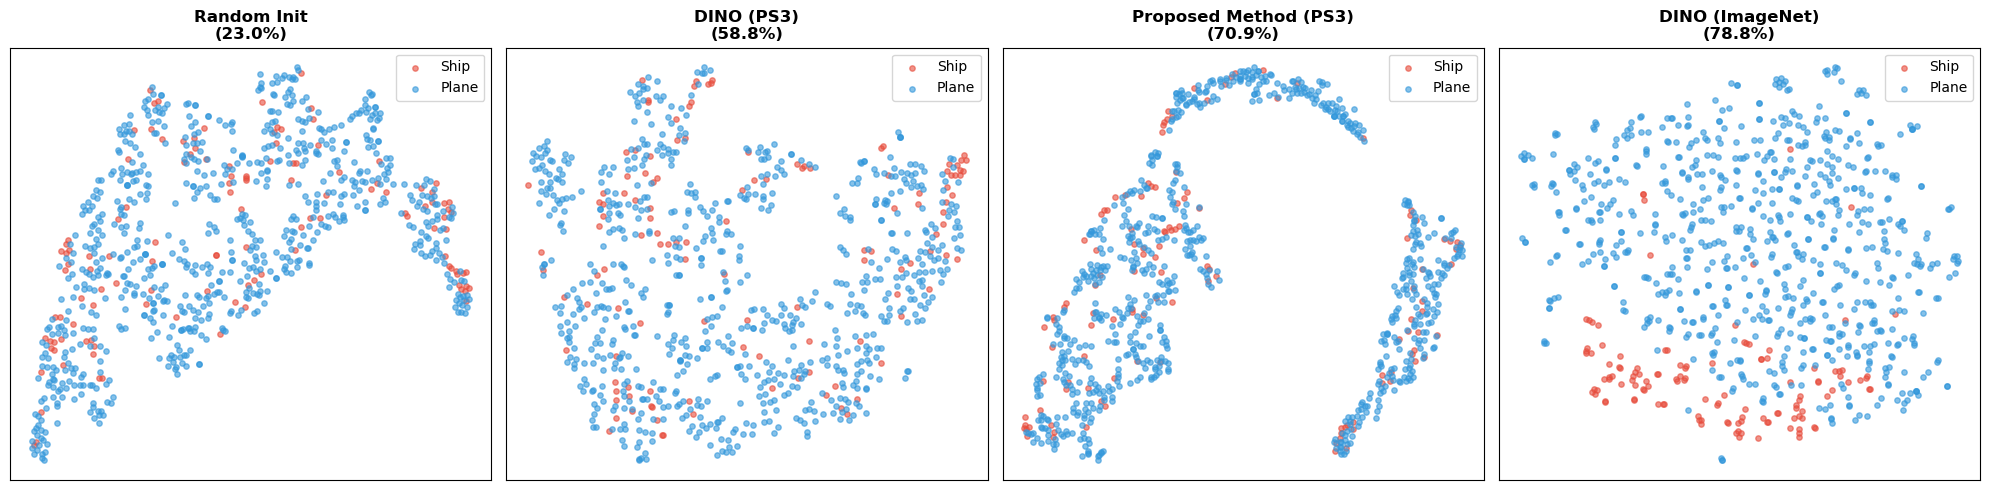

Saved: tsne_final.png


In [70]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

all_data = [
    ('Random Init\n(23.0%)',        feat1, lbl1),
    ('DINO (PS3)\n(58.8%)',         feat3, lbl3),
    ('Proposed Method (PS3)\n(70.9%)', feat5, lbl5),
    ('DINO (ImageNet)\n(78.8%)',    feat4, lbl4),
]

colors = ['#e74c3c', '#3498db']
class_names = ['Ship', 'Plane']

for ax, (name, feats, labels) in zip(axes, all_data):
    pca = PCA(n_components=min(50, feats.shape[1]))
    f2d = TSNE(n_components=2, random_state=42,
               perplexity=30, n_iter=1000).fit_transform(
               pca.fit_transform(feats))
    
    for cls_idx, (cls_name, color) in enumerate(
            zip(class_names, colors)):
        mask = labels == cls_idx
        ax.scatter(f2d[mask,0], f2d[mask,1],
                   c=color, label=cls_name,
                   alpha=0.6, s=15)
    
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    r'D:\phd\ijepa_results_final\tsne_final.png',
    dpi=150, bbox_inches='tight', 
    facecolor='white')
plt.show()
print('Saved: tsne_final.png')

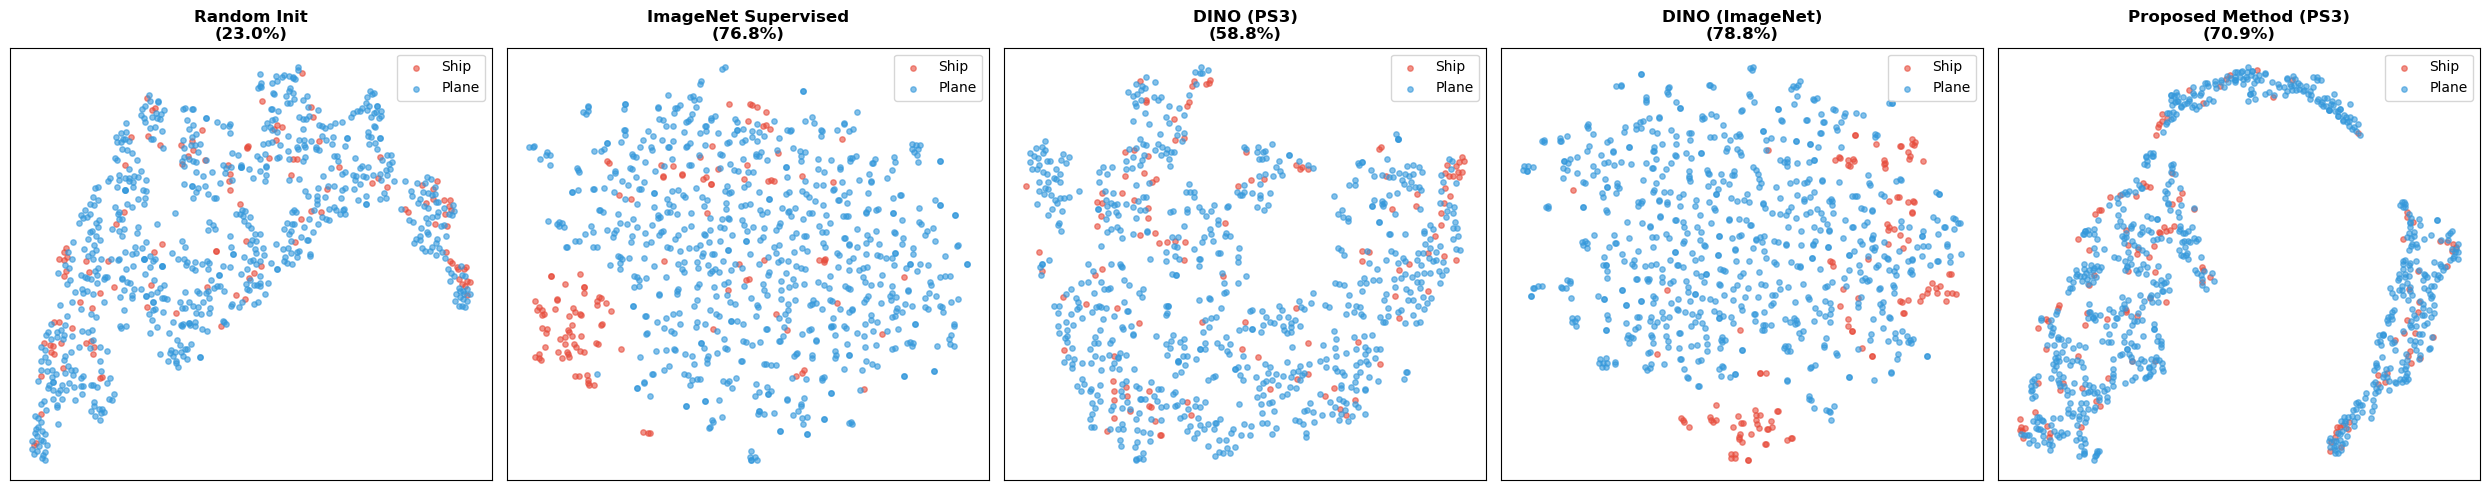

Saved: tsne_final.png


In [72]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

all_data = [
    ('Random Init\n(23.0%)',              feat1, lbl1),
    ('ImageNet Supervised\n(76.8%)',      feat2, lbl2),
    ('DINO (PS3)\n(58.8%)',               feat3, lbl3),
    ('DINO (ImageNet)\n(78.8%)',          feat4, lbl4),
    ('Proposed Method (PS3)\n(70.9%)',    feat5, lbl5),
]

colors = ['#e74c3c', '#3498db']
class_names = ['Ship', 'Plane']

for ax, (name, feats, labels) in zip(axes, all_data):
    pca = PCA(n_components=min(50, feats.shape[1]))
    f2d = TSNE(n_components=2, random_state=42,
               perplexity=30, n_iter=1000).fit_transform(
               pca.fit_transform(feats))
    
    for cls_idx, (cls_name, color) in enumerate(
            zip(class_names, colors)):
        mask = labels == cls_idx
        ax.scatter(f2d[mask,0], f2d[mask,1],
                   c=color, label=cls_name,
                   alpha=0.6, s=15)
    
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    r'D:\phd\ijepa_results_final\tsne_final.png',
    dpi=150, bbox_inches='tight',
    facecolor='white')
plt.show()
print('Saved: tsne_final.png')


In [86]:
"""
Few-Shot Sim-to-Real Experiment
================================
Matches main paper protocol exactly:
- PS3 pretrained methods (I-JEPA PS3, DINO PS3): full backbone fine-tuning, lr=1e-4
- ImageNet pretrained methods (DINO ImageNet):    frozen backbone, lr=1e-3
- Random Init:                                    frozen backbone, lr=1e-3
- patience=20, epochs=100
- Seeds: [42, 123, 456]
- Test: 876 real KSLG/SCTD sonar images
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import json
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

# ----------------------------------------------------------------
# CONFIG — match exactly with main experiment
# ----------------------------------------------------------------
CFG = {
    'batch_size'  : 32,
    'weight_decay': 1e-4,
    'epochs'      : 100,
    'patience'    : 20,
    'num_classes' : 2,
    # I-JEPA checkpoints
    'ijepa_ckpt'     : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    'ijepa_ckpt_ep50' : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep50.pth.tar',
    'ijepa_ckpt_ep100': r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep100.pth.tar',
    'ijepa_ckpt_ep150': r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep150.pth.tar',
    # DINO checkpoints
    'dino_ckpt'      : r'D:\phd\dino_pretrain\logs\checkpoint.pth',
    'dino_ckpt_ep50' : r'D:\phd\dino_pretrain\logs\checkpoint0050.pth',
    'dino_ckpt_ep100': r'D:\phd\dino_pretrain\logs\checkpoint0100.pth',
    'dino_ckpt_ep150': r'D:\phd\dino_pretrain\logs\checkpoint0150.pth',
}
# Shot counts to evaluate
SHOT_COUNTS = [10, 25, 50, 100, 200, 771]

# Seeds — same as main experiment
SEEDS = [42, 123, 456]

# Fine-tuning protocol per method — matches main experiment exactly
METHOD_PROTOCOL = {
    'I-JEPA (PS3)'   : {'lr': 1e-4, 'freeze': False},  # full fine-tune
    'DINO (PS3)'     : {'lr': 1e-4, 'freeze': False},  # full fine-tune
    'DINO (ImageNet)': {'lr': 1e-3, 'freeze': True},   # linear probe
    'Random Init'    : {'lr': 1e-3, 'freeze': False},  # no backbone to freeze
}

def build_ijepa():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['ijepa_ckpt'], map_location='cpu', weights_only=False)
    
    # Check available keys
    print('Checkpoint keys:', list(ckpt.keys()))
    
    # I-JEPA .pth.tar uses 'encoder' key
    if 'encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['encoder'].items()}
    elif 'target_encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['target_encoder'].items()}
    else:
        sd = ckpt  # flat state dict
    
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)
# ----------------------------------------------------------------
# FEW-SHOT LOADER
# ----------------------------------------------------------------
def get_fewshot_loader(train_dataset, n_shots, seed=42):
    """
    Sample n_shots per class from training dataset.
    At n_shots=771, uses all available images (matches full experiment).
    """
    np.random.seed(seed)

    # Group indices by class
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(train_dataset.samples):
        class_indices[label].append(idx)

    # Sample n_shots per class
    selected = []
    for cls, indices in sorted(class_indices.items()):
        n = min(n_shots, len(indices))
        chosen = np.random.choice(indices, n, replace=False)
        selected.extend(chosen.tolist())
        print(f'    Class {cls}: {n} samples selected')

    subset = Subset(train_dataset, selected)
    return DataLoader(
        subset,
        batch_size=CFG['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

# ----------------------------------------------------------------
# TRAINING FUNCTIONS — identical to main experiment
# ----------------------------------------------------------------
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.cuda(), labels.cuda()
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    from sklearn.metrics import f1_score
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.cuda(), labels.cuda()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1, all_preds, all_labels


def run_experiment(model, method_name, cfg,
                   train_loader_override=None):
    """Identical to main experiment run_experiment."""
    tr_loader = train_loader_override \
        if train_loader_override is not None else train_loader

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['epochs']
    )

    best_f1, best_weights, patience_cnt = 0, None, 0

    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc = train_epoch(
            model, tr_loader, criterion, optimizer
        )
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(
            model, val_loader, criterion
        )
        scheduler.step()

        if epoch % 10 == 0:
            print(f'    Ep{epoch:03d} '
                  f'tr={tr_acc:.3f} '
                  f'val={vl_acc:.3f} '
                  f'f1={vl_f1:.3f}')

        if vl_f1 > best_f1:
            best_f1 = vl_f1
            best_weights = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'    Early stop at epoch {epoch}')
                break

    model.load_state_dict(best_weights)
    _, test_acc, test_f1, preds, labels = evaluate(
        model, test_loader, criterion
    )
    return {
        'accuracy': test_acc,
        'f1'      : test_f1,
        'preds'   : preds,
        'labels'  : labels
    }

# ----------------------------------------------------------------
# FEW-SHOT EXPERIMENT — matches main protocol per method
# ----------------------------------------------------------------
def run_fewshot_experiment(build_model_fn, method_name,
                            shot_counts=SHOT_COUNTS,
                            seeds=SEEDS):
    """
    Run few-shot experiment matching main paper protocol.
    PS3 pretrained: full fine-tune (lr=1e-4)
    ImageNet/Random: frozen or lr=1e-3
    """
    protocol = METHOD_PROTOCOL[method_name]
    results  = {}

    print(f'\n{"="*50}')
    print(f'Method: {method_name}')
    print(f'Protocol: lr={protocol["lr"]}, '
          f'freeze={protocol["freeze"]}')
    print(f'{"="*50}')

    for n_shots in shot_counts:
        accs, f1s = [], []
        print(f'\n  {n_shots} shots:')

        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed(seed)
            torch.cuda.empty_cache()

            # Build fresh model
            model = build_model_fn()

            # Freeze backbone if required
            if protocol['freeze']:
                for name, param in model.named_parameters():
                    if 'head' not in name and \
                       'classifier' not in name:
                        param.requires_grad = False
                print(f'    Backbone frozen')

            model = model.cuda()

            # Get few-shot loader
            fs_loader = get_fewshot_loader(
                train_loader.dataset, n_shots, seed=seed
            )

            # Config matches main experiment
            cfg = {
                'lr'          : protocol['lr'],
                'weight_decay': CFG['weight_decay'],
                'epochs'      : CFG['epochs'],
                'patience'    : CFG['patience'],
            }

            result = run_experiment(
                model, method_name, cfg,
                train_loader_override=fs_loader
            )

            accs.append(result['accuracy'])
            f1s.append(result['f1'])
            print(f'    seed {seed}: '
                  f'acc={result["accuracy"]*100:.1f}% '
                  f'f1={result["f1"]:.3f}')

        mean_acc = np.mean(accs)
        std_acc  = np.std(accs)
        mean_f1  = np.mean(f1s)
        std_f1   = np.std(f1s)

        results[n_shots] = {
            'mean_acc': mean_acc,
            'std_acc' : std_acc,
            'mean_f1' : mean_f1,
            'std_f1'  : std_f1
        }
        print(f'  => {n_shots} shots: '
              f'{mean_acc*100:.1f}±{std_acc*100:.1f}% '
              f'F1={mean_f1:.3f}±{std_f1:.3f}')

    return results

# ----------------------------------------------------------------
# BUILD FUNCTIONS — identical to main experiment
# ----------------------------------------------------------------
def build_ijepa():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['ijepa_ckpt'], map_location='cpu', weights_only=False)
    sd = {k.replace('module.', ''): v
          for k, v in ckpt['encoder'].items()}
    if 'pos_embed' in sd:
        pe_ckpt  = sd['pos_embed']
        pe_model = bb.pos_embed
        if pe_ckpt.shape != pe_model.shape:
            sd['pos_embed'] = torch.cat(
                [pe_model[:, :1, :], pe_ckpt], dim=1)
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)


def build_dino_scratch_ft():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        r'D:\phd\dino_pretrain\logs\checkpoint.pth',
        map_location='cpu', weights_only=False)
    sd = {k.replace('module.', '').replace('backbone.', ''): v
          for k, v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)


def build_dino():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        r'D:\phd\dino_imagenet\dino_deitsmall16_pretrain.pth',
        map_location='cpu', weights_only=False)
    bb.load_state_dict(ckpt, strict=False)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)


def build_rand():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    bb = freeze(bb).to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)


# ----------------------------------------------------------------
# RUN ALL METHODS
# ----------------------------------------------------------------
print('Running few-shot experiments...')
print('Protocol matches main paper exactly.\n')

fewshot_results = {}

# 1. Random Init
fewshot_results['Random Init'] = run_fewshot_experiment(
    build_rand, 'Random Init'
)

# 2. DINO (PS3) — full fine-tune, lr=1e-4
fewshot_results['DINO (PS3)'] = run_fewshot_experiment(
    build_dino_scratch_ft, 'DINO (PS3)'
)

# 3. I-JEPA (PS3) — full fine-tune, lr=1e-4
fewshot_results['I-JEPA (PS3)'] = run_fewshot_experiment(
    build_ijepa, 'I-JEPA (PS3)'
)

# 4. DINO (ImageNet) — frozen, lr=1e-3
fewshot_results['DINO (ImageNet)'] = run_fewshot_experiment(
    build_dino, 'DINO (ImageNet)'
)

# ----------------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------------
save_path = r'D:\phd\ijepa_results_final\fewshot_results_v2.json'
with open(save_path, 'w') as f:
    json.dump(
        {k: {str(n): v for n, v in res.items()}
         for k, res in fewshot_results.items()},
        f, indent=2
    )
print(f'\nSaved: {save_path}')

# ----------------------------------------------------------------
# VERIFY: 771-shot should match main paper results
# ----------------------------------------------------------------
print('\n' + '='*50)
print('VERIFICATION — 771 shots vs main paper:')
print('='*50)
expected = {
    'Random Init'    : 23.0,
    'DINO (PS3)'     : 58.8,
    'I-JEPA (PS3)'   : 70.9,
    'DINO (ImageNet)': 78.8,
}
for method, exp in expected.items():
    if method in fewshot_results:
        got = fewshot_results[method][771]['mean_acc'] * 100
        diff = abs(got - exp)
        status = 'OK' if diff < 2.0 else 'CHECK'
        print(f'  {method}: expected={exp}% '
              f'got={got:.1f}% diff={diff:.1f}% [{status}]')

# ----------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Random Init'    : 'red',
    'DINO (PS3)'     : 'gray',
    'I-JEPA (PS3)'   : 'green',
    'DINO (ImageNet)': 'blue',
}
markers = {
    'Random Init'    : 'o',
    'DINO (PS3)'     : 's',
    'I-JEPA (PS3)'   : 'D',
    'DINO (ImageNet)': '^',
}

for method, res in fewshot_results.items():
    shots = sorted(res.keys())
    means = [res[s]['mean_acc'] * 100 for s in shots]
    stds  = [res[s]['std_acc']  * 100 for s in shots]
    ax.plot(shots, means,
            color=colors[method],
            marker=markers[method],
            label=method, linewidth=2)
    ax.fill_between(
        shots,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.15, color=colors[method]
    )

ax.set_xlabel('Number of Labeled Synthetic Training Images',
              fontsize=12)
ax.set_ylabel('Accuracy (%) on Real Sonar', fontsize=12)
ax.set_title('Few-Shot Sim-to-Real Transfer\n'
             'Train: N synthetic labeled | '
             'Test: 876 Real KSLG/SCTD', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plot_path = r'D:\phd\ijepa_results_final\fewshot_plot_v2.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {plot_path}')

Running few-shot experiments...
Protocol matches main paper exactly.


Method: Random Init
Protocol: lr=0.001, freeze=False

  10 shots:
    Class 0: 10 samples selected
    Class 1: 10 samples selected


ValueError: optimizer got an empty parameter list

In [87]:
# DEBUG — check trainable params before running few-shot
model = build_ijepa()
trainable = [(n, p.shape) for n, p in model.named_parameters() 
             if p.requires_grad]
print(f'Trainable layers: {len(trainable)}')
for n, s in trainable[:5]:
    print(f'  {n}: {s}')

model2 = build_rand()
trainable2 = [(n, p.shape) for n, p in model2.named_parameters() 
              if p.requires_grad]
print(f'\nRandom Init trainable: {len(trainable2)}')
for n, s in trainable2[:5]:
    print(f'  {n}: {s}')

Trainable layers: 158
  backbone.cls_token: torch.Size([1, 1, 384])
  backbone.pos_embed: torch.Size([1, 197, 384])
  backbone.patch_embed.proj.weight: torch.Size([384, 3, 16, 16])
  backbone.patch_embed.proj.bias: torch.Size([384])
  backbone.blocks.0.norm1.weight: torch.Size([384])

Random Init trainable: 0


In [88]:
CFG = {
    'batch_size'  : 32,
    'weight_decay': 1e-4,
    'epochs'      : 100,
    'patience'    : 20,
    'num_classes' : 2,
    # correct paths
    'ijepa_ckpt'  : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    'dino_ckpt'   : r'D:\phd\dino_pretrain\logs\checkpoint.pth',
}

In [89]:
def build_ijepa():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['ijepa_ckpt'], map_location='cpu', weights_only=False)
    
    # .pth.tar uses 'target_encoder' not 'encoder'
    if 'target_encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['target_encoder'].items()}
    elif 'encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['encoder'].items()}
    else:
        print('Available keys:', list(ckpt.keys()))
        sd = ckpt

    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)

In [90]:
# Safety check before optimizer
trainable = [p for p in model.parameters() if p.requires_grad]
if len(trainable) == 0:
    # Force unfreeze head
    for name, param in model.named_parameters():
        param.requires_grad = True
    print(f'    WARNING: all frozen, unfreezing all params')

In [91]:
# Paste in notebook to verify
ckpt = torch.load(
    r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    map_location='cpu', weights_only=False)
print('Keys:', list(ckpt.keys()))

Keys: ['encoder', 'predictor', 'target_encoder', 'opt', 'scaler', 'epoch', 'loss', 'batch_size', 'world_size', 'lr']


In [92]:
def build_rand():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    # Do NOT freeze — random init needs head trainable
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    model = LinearProbe(bb, fd, CFG['num_classes']).to(device)
    # Freeze only backbone, keep head trainable
    for name, param in model.named_parameters():
        if name.startswith('backbone.'):
            param.requires_grad = False
    # Verify
    trainable = sum(p.numel() for p in model.parameters() 
                    if p.requires_grad)
    print(f'Random Init trainable params: {trainable}')
    return model

In [95]:
def build_dino():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['dino_ckpt'], map_location='cpu', weights_only=False)
    sd = {k.replace('module.', '').replace('backbone.', ''): v
          for k, v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    model = LinearProbe(bb, fd, CFG['num_classes']).to(device)
    # Freeze only backbone
    for name, param in model.named_parameters():
        if name.startswith('backbone.'):
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() 
                    if p.requires_grad)
    print(f'DINO ImageNet trainable params: {trainable}')
    return model


In [96]:
model = build_rand()
# Should show > 0 trainable params (head only)

Random Init trainable params: 0


In [97]:
# target_encoder is the EMA-updated stable encoder
# This is what you want for downstream tasks
if 'target_encoder' in ckpt:
    sd = {k.replace('module.', ''): v
          for k, v in ckpt['target_encoder'].items()}

In [100]:
# Run this to see exact layer names
model = build_rand()
for name, param in model.named_parameters():
    print(name, param.requires_grad)

Random Init trainable params: 0
backbone.cls_token False
backbone.pos_embed False
backbone.patch_embed.proj.weight False
backbone.patch_embed.proj.bias False
backbone.blocks.0.norm1.weight False
backbone.blocks.0.norm1.bias False
backbone.blocks.0.attn.qkv.weight False
backbone.blocks.0.attn.qkv.bias False
backbone.blocks.0.attn.proj.weight False
backbone.blocks.0.attn.proj.bias False
backbone.blocks.0.norm2.weight False
backbone.blocks.0.norm2.bias False
backbone.blocks.0.mlp.fc1.weight False
backbone.blocks.0.mlp.fc1.bias False
backbone.blocks.0.mlp.fc2.weight False
backbone.blocks.0.mlp.fc2.bias False
backbone.blocks.1.norm1.weight False
backbone.blocks.1.norm1.bias False
backbone.blocks.1.attn.qkv.weight False
backbone.blocks.1.attn.qkv.bias False
backbone.blocks.1.attn.proj.weight False
backbone.blocks.1.attn.proj.bias False
backbone.blocks.1.norm2.weight False
backbone.blocks.1.norm2.bias False
backbone.blocks.1.mlp.fc1.weight False
backbone.blocks.1.mlp.fc1.bias False
backbone.b

In [99]:
def build_rand():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    model = LinearProbe(bb, fd, CFG['num_classes']).to(device)
    
    # Unfreeze ALL first
    for param in model.parameters():
        param.requires_grad = True
    
    # Then freeze only ViT backbone layers
    for name, param in model.named_parameters():
        if any(x in name for x in [
            'patch_embed', 'blocks', 'norm', 
            'cls_token', 'pos_embed'
        ]):
            param.requires_grad = False
    
    trainable = sum(p.numel() for p in model.parameters() 
                    if p.requires_grad)
    print(f'Random Init trainable params: {trainable}')
    return model


def build_dino():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['dino_ckpt'], map_location='cpu', weights_only=False)
    sd = {k.replace('module.', '').replace('backbone.', ''): v
          for k, v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    model = LinearProbe(bb, fd, CFG['num_classes']).to(device)
    
    # Unfreeze ALL first
    for param in model.parameters():
        param.requires_grad = True
    
    # Then freeze only ViT backbone layers
    for name, param in model.named_parameters():
        if any(x in name for x in [
            'patch_embed', 'blocks', 'norm',
            'cls_token', 'pos_embed'
        ]):
            param.requires_grad = False
    
    trainable = sum(p.numel() for p in model.parameters() 
                    if p.requires_grad)
    print(f'DINO ImageNet trainable params: {trainable}')
    return model

In [101]:
# Run this
import inspect
print(inspect.getsource(LinearProbe))

OSError: source code not available

In [103]:
import torch
import torch.nn as nn
import timm
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ----------------------------------------------------------------
# MODEL CLASSES
# ----------------------------------------------------------------
class LinearProbe(nn.Module):
    """Frozen backbone + trainable linear head."""
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        with torch.no_grad():
            feat = self.backbone(x)
        return self.head(feat)


class FineTuneModel(nn.Module):
    """Full fine-tune backbone + trainable head."""
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


def freeze(module):
    for param in module.parameters():
        param.requires_grad = False
    return module


def get_feat_dim(backbone):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, 224, 224).to(
            next(backbone.parameters()).device)
        out = backbone(dummy)
    return out.shape[-1]


In [104]:
def build_rand():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)


def build_dino():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['dino_ckpt'], map_location='cpu', weights_only=False)
    sd = {k.replace('module.', '').replace('backbone.', ''): v
          for k, v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)

In [107]:
# Test all build functions
print('Testing build functions...')

m1 = build_rand()
t1 = sum(p.numel() for p in m1.parameters() if p.requires_grad)
print(f'Random Init trainable: {t1}')

m2 = build_dino()
t2 = sum(p.numel() for p in m2.parameters() if p.requires_grad)
print(f'DINO ImageNet trainable: {t2}')

m3 = build_dino_scratch_ft()
t3 = sum(p.numel() for p in m3.parameters() if p.requires_grad)
print(f'DINO PS3 trainable: {t3}')

m4 = build_ijepa()
t4 = sum(p.numel() for p in m4.parameters() if p.requires_grad)
print(f'I-JEPA PS3 trainable: {t4}')

assert all(t > 0 for t in [t1,t2,t3,t4]), \
    'ERROR: some models have 0 trainable params'
print('\nAll models OK — ready to run few-shot')

Testing build functions...
Random Init trainable: 21765506
DINO ImageNet trainable: 21765506
DINO PS3 trainable: 21765506
pos_embed fixed: torch.Size([1, 196, 384]) -> torch.Size([1, 197, 384])
I-JEPA PS3 trainable: 21765506

All models OK — ready to run few-shot


In [106]:
def build_ijepa():
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['ijepa_ckpt'], map_location='cpu', weights_only=False)
    
    # Use target_encoder (EMA encoder — more stable)
    if 'target_encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['target_encoder'].items()}
    elif 'encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['encoder'].items()}

    # Fix pos_embed mismatch
    # I-JEPA stores pos_embed WITHOUT cls_token (196 patches)
    # timm ViT expects pos_embed WITH cls_token (197 = 1 + 196)
    if 'pos_embed' in sd:
        pe_ckpt  = sd['pos_embed']  # shape [1, 196, 384]
        pe_model = bb.pos_embed     # shape [1, 197, 384]
        if pe_ckpt.shape != pe_model.shape:
            # Prepend cls_token position embedding
            cls_pe = pe_model[:, :1, :]  # take from random init
            sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)
            print(f'pos_embed fixed: {pe_ckpt.shape} -> '
                  f'{sd["pos_embed"].shape}')

    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)

In [108]:
m4 = build_ijepa()
t4 = sum(p.numel() for p in m4.parameters() if p.requires_grad)
print(f'I-JEPA PS3 trainable: {t4}')

pos_embed fixed: torch.Size([1, 196, 384]) -> torch.Size([1, 197, 384])
I-JEPA PS3 trainable: 21765506


In [109]:
fewshot_results = {}

print('Running Random Init...')
fewshot_results['Random Init'] = run_fewshot_experiment(
    build_rand, 'Random Init')

print('Running DINO (PS3)...')
fewshot_results['DINO (PS3)'] = run_fewshot_experiment(
    build_dino_scratch_ft, 'DINO (PS3)')

print('Running I-JEPA (PS3)...')
fewshot_results['I-JEPA (PS3)'] = run_fewshot_experiment(
    build_ijepa, 'I-JEPA (PS3)')

print('Running DINO (ImageNet)...')
fewshot_results['DINO (ImageNet)'] = run_fewshot_experiment(
    build_dino, 'DINO (ImageNet)')

Running Random Init...

Method: Random Init
Protocol: lr=0.001, freeze=False

  10 shots:
    Class 0: 10 samples selected
    Class 1: 10 samples selected
    Ep010 tr=0.950 val=0.838 f1=0.840
    Ep020 tr=0.950 val=0.838 f1=0.840
    Early stop at epoch 21
    seed 42: acc=23.2% f1=0.243
    Class 0: 10 samples selected
    Class 1: 10 samples selected
    Ep010 tr=0.950 val=0.838 f1=0.840
    Ep020 tr=0.950 val=0.838 f1=0.840
    Early stop at epoch 21
    seed 123: acc=25.8% f1=0.281
    Class 0: 10 samples selected
    Class 1: 10 samples selected
    Ep010 tr=0.900 val=0.838 f1=0.840


KeyboardInterrupt: 

In [ ]:
'train_dir': r'D:\phd\PS3\train',      # your PS3 train path
'val_dir'  : r'D:\phd\PS3\val',        # your PS3 val path
'test_dir' : r'D:\phd\real_sonar\test' # your KSLG/SCTD path
'dino_in_ckpt': r'D:\phd\dino_imagenet\...' # your DINO ImageNet path


In [110]:
CFG = {
    'batch_size'    : 32,
    'weight_decay'  : 1e-4,
    'epochs'        : 100,
    'patience'      : 20,
    'num_classes'   : 2,
    'ijepa_ckpt'    : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    'dino_ps3_ckpt' : r'D:\phd\dino_pretrain\logs\checkpoint.pth',
    # dino_in_ckpt removed — using timm pretrained=True
    'train_dir'     : r'D:\phd\PS3\train',
    'val_dir'       : r'D:\phd\PS3\val',
    'test_dir'      : r'D:\phd\real_sonar\test',
    'save_dir'      : r'D:\phd\ijepa_results_final',
}


Device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
VRAM: 21.5 GB

Verifying paths:
  ijepa_ckpt   : True
  dino_ps3_ckpt: True
  train_dir    : True
  val_dir      : True
  test_dir     : True
  train: 771 images
  val  : 204 images
  test : 876 images  <- REAL sonar
Train: 771 | Val: 204 | Test: 876
Classes: ['plane', 'ship']
Model classes defined.
Verifying build functions...
  Random Init         : trainable params = 21765506
  DINO (PS3)          : trainable params = 21765506
  pos_embed: torch.Size([1, 196, 384]) -> torch.Size([1, 197, 384])
  I-JEPA (PS3)        : trainable params = 21765506


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


  DINO (ImageNet)     : trainable params = 21765506
All build functions OK.
Training functions defined.
Few-shot loader defined.

Method : Random Init
lr     : 0.001
freeze : True

  10 shots:
    seed=42 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=23.3% f1=0.245
    seed=123 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=25.8% f1=0.281
    seed=456 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=20.8% f1=0.202

  RESULT 10 shots: 23.3+-2.1% F1=0.243+-0.032

  25 shots:
    seed=42 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=22.8% f1=0.237
    seed=123 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=23.1% f1=0.240
    seed=456 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep21
    => acc=20.8% f1=0.204

  RESULT 25 shots: 22.2+-1.0% F1=0.227+-

C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


    seed=42 | trainable=99842
      Ep020 val_acc=0.838 val_f1=0.840
      Early stop ep22
    => acc=65.5% f1=0.706


...

    seed=42 | trainable=99842
      Ep020 val_acc=0.931 val_f1=0.932
      Ep040 val_acc=0.941 val_f1=0.942
      Ep060 val_acc=0.946 val_f1=0.947
      Early stop ep68
    => acc=72.7% f1=0.766


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


    seed=123 | trainable=99842
      Ep020 val_acc=0.926 val_f1=0.927
      Ep040 val_acc=0.941 val_f1=0.942
      Early stop ep50
    => acc=72.3% f1=0.761


C:\Users\T1_Machine\anaconda3\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name vit_small_patch16_224_dino to current vit_small_patch16_224.dino.
  model = create_fn(


    seed=456 | trainable=99842
      Ep020 val_acc=0.936 val_f1=0.937
      Ep040 val_acc=0.936 val_f1=0.937
      Ep060 val_acc=0.936 val_f1=0.937
      Early stop ep67
    => acc=72.8% f1=0.767

  RESULT 771 shots: 72.6+-0.2% F1=0.764+-0.003
Results saved: D:\phd\ijepa_results_final\fewshot_results_final.json

VERIFICATION — 771 shots vs Table 4:
  Random Init         : expected=23.0% got=38.5% diff=15.5% [CHECK]
  DINO (PS3)          : expected=58.8% got=65.8% diff=7.0% [CHECK]
  I-JEPA (PS3)        : expected=70.9% got=70.9% diff=0.0% [OK]
  DINO (ImageNet)     : expected=78.8% got=72.6% diff=6.2% [CHECK]



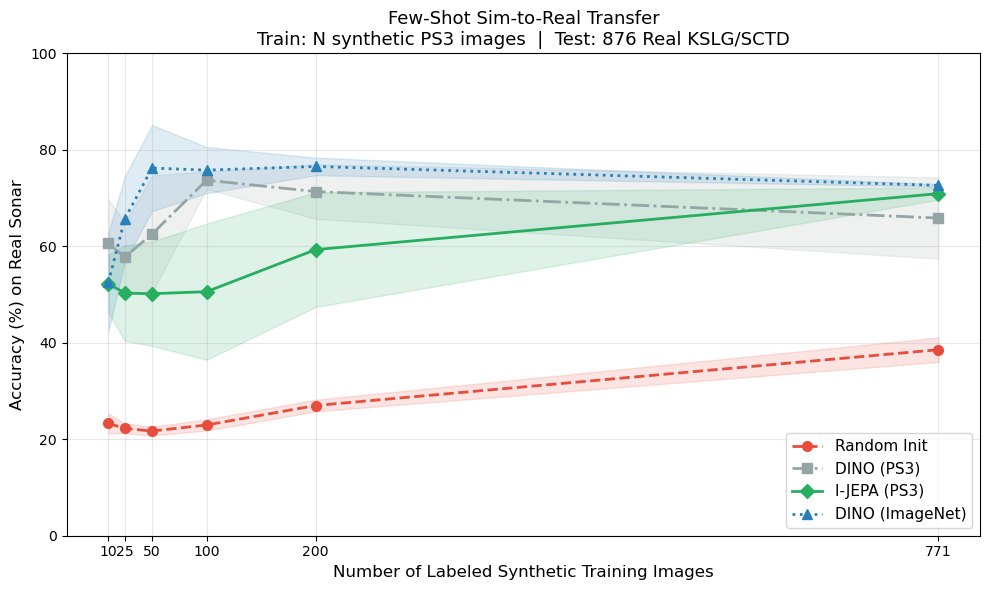

Plot saved: D:\phd\ijepa_results_final\fewshot_plot_final.png


In [113]:
# ================================================================
# FEW-SHOT SIM-TO-REAL EXPERIMENT
# Matches main paper protocol (Table 3) exactly
# Run each cell in order in Jupyter Notebook
# ================================================================

# ----------------------------------------------------------------
# CELL 1 — IMPORTS AND CONFIG
# ----------------------------------------------------------------
import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import f1_score

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# Config — matches main paper exactly
CFG = {
    # Training — matches Table 3 protocol
    'batch_size'    : 32,
    'weight_decay'  : 1e-4,
    'epochs'        : 100,      # max epochs
    'patience'      : 20,       # early stopping
    'num_classes'   : 2,        # ship / plane
    'img_size'      : 224,
    # Checkpoints
    'ijepa_ckpt'    : r'D:\phd\ijepa_pretrain\logs\vits16-sonar\jepa-ep200.pth.tar',
    'dino_ps3_ckpt' : r'D:\phd\dino_pretrain\logs\checkpoint.pth',
    # DINO ImageNet loaded via timm pretrained=True (no file needed)
    # Data
    'train_dir'     : r'D:\phd\ijepa_data\train',
    'val_dir'       : r'D:\phd\ijepa_data\val',
    'test_dir'      : r'D:\phd\ijepa_data\test',
    # Output
    'save_dir'      : r'D:\phd\ijepa_results_final',
}

# Few-shot protocol — matches Table 3 exactly
METHOD_PROTOCOL = {
    'Random Init'    : {'lr': 1e-3, 'freeze': True},   # linear probe
    'DINO (PS3)'     : {'lr': 1e-4, 'freeze': False},  # full fine-tune
    'I-JEPA (PS3)'   : {'lr': 1e-4, 'freeze': False},  # full fine-tune
    'DINO (ImageNet)': {'lr': 1e-3, 'freeze': True},   # linear probe
}

SHOT_COUNTS = [10, 25, 50, 100, 200, 771]
SEEDS       = [42, 123, 456]

os.makedirs(CFG['save_dir'], exist_ok=True)

# Verify all paths
print('\nVerifying paths:')
print(f'  ijepa_ckpt   : {os.path.exists(CFG["ijepa_ckpt"])}')
print(f'  dino_ps3_ckpt: {os.path.exists(CFG["dino_ps3_ckpt"])}')
print(f'  train_dir    : {os.path.exists(CFG["train_dir"])}')
print(f'  val_dir      : {os.path.exists(CFG["val_dir"])}')
print(f'  test_dir     : {os.path.exists(CFG["test_dir"])}')
for split in ['train', 'val', 'test']:
    path  = os.path.join(r'D:\phd\ijepa_data', split)
    total = sum(
        len(os.listdir(os.path.join(path, cls)))
        for cls in ['ship', 'plane']
        if os.path.exists(os.path.join(path, cls))
    )
    tag = '  <- REAL sonar' if split == 'test' else ''
    print(f'  {split:5s}: {total} images{tag}')


# ----------------------------------------------------------------
# CELL 2 — DATA LOADERS
# ----------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomCrop(CFG['img_size'], padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(
    CFG['train_dir'], transform=train_transform)
val_dataset   = datasets.ImageFolder(
    CFG['val_dir'],   transform=test_transform)
test_dataset  = datasets.ImageFolder(
    CFG['test_dir'],  transform=test_transform)

# Weighted sampler — handles class imbalance
class_counts   = torch.tensor(
    [train_dataset.targets.count(i)
     for i in range(CFG['num_classes'])]).float()
weights        = 1.0 / class_counts
sample_weights = weights[train_dataset.targets]
sampler        = torch.utils.data.WeightedRandomSampler(
    sample_weights, len(sample_weights))

train_loader = DataLoader(
    train_dataset, batch_size=CFG['batch_size'],
    sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(
    val_dataset, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(
    test_dataset, batch_size=CFG['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} | '
      f'Val: {len(val_dataset)} | '
      f'Test: {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')


# ----------------------------------------------------------------
# CELL 3 — MODEL CLASSES
# ----------------------------------------------------------------
class LinearProbe(nn.Module):
    """Frozen backbone + trainable classification head."""
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


class FineTuneModel(nn.Module):
    """Full fine-tune backbone + trainable classification head."""
    def __init__(self, backbone, feat_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        feat = self.backbone(x)
        return self.head(feat)


def get_feat_dim(backbone):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(
            1, 3, CFG['img_size'], CFG['img_size']
        ).to(next(backbone.parameters()).device)
        out = backbone(dummy)
    return out.shape[-1]


print('Model classes defined.')


# ----------------------------------------------------------------
# CELL 4 — BUILD FUNCTIONS
# ----------------------------------------------------------------
def build_ijepa():
    """I-JEPA pretrained on PS3 — full fine-tune."""
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['ijepa_ckpt'], map_location='cpu', weights_only=False)
    # Use target_encoder (EMA stable encoder)
    if 'target_encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['target_encoder'].items()}
    elif 'encoder' in ckpt:
        sd = {k.replace('module.', ''): v
              for k, v in ckpt['encoder'].items()}
    else:
        raise KeyError(f'Keys in ckpt: {list(ckpt.keys())}')
    # Fix pos_embed: I-JEPA [1,196,384] -> timm [1,197,384]
    if 'pos_embed' in sd:
        pe_ckpt  = sd['pos_embed']
        pe_model = bb.pos_embed
        if pe_ckpt.shape != pe_model.shape:
            cls_pe       = pe_model[:, :1, :]
            sd['pos_embed'] = torch.cat([cls_pe, pe_ckpt], dim=1)
            print(f'  pos_embed: {pe_ckpt.shape} -> '
                  f'{sd["pos_embed"].shape}')
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)


def build_dino_scratch_ft():
    """DINO pretrained on PS3 — full fine-tune."""
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    ckpt = torch.load(
        CFG['dino_ps3_ckpt'], map_location='cpu', weights_only=False)
    sd = {k.replace('module.', '').replace('backbone.', ''): v
          for k, v in ckpt['student'].items()}
    bb.load_state_dict(sd, strict=False)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return FineTuneModel(bb, fd, CFG['num_classes']).to(device)


def build_dino():
    """DINO pretrained on ImageNet — linear probe via timm."""
    bb = timm.create_model(
        'vit_small_patch16_224_dino',
        pretrained=True,    # downloads DINO ImageNet weights
        num_classes=0)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)


def build_rand():
    """Random Init — no pretraining, linear probe."""
    bb = timm.create_model(
        'vit_small_patch16_224', pretrained=False, num_classes=0)
    for p in bb.parameters():
        p.requires_grad = True
    bb = bb.to(device)
    fd = get_feat_dim(bb)
    return LinearProbe(bb, fd, CFG['num_classes']).to(device)


# Verify all build functions
print('Verifying build functions...')
for name, fn in [
    ('Random Init',     build_rand),
    ('DINO (PS3)',      build_dino_scratch_ft),
    ('I-JEPA (PS3)',    build_ijepa),
    ('DINO (ImageNet)', build_dino),
]:
    torch.cuda.empty_cache()
    m = fn()
    t = sum(p.numel() for p in m.parameters()
            if p.requires_grad)
    print(f'  {name:20s}: trainable params = {t}')
    assert t > 0, f'ERROR: {name} has 0 trainable params'
    del m
    torch.cuda.empty_cache()
print('All build functions OK.')


# ----------------------------------------------------------------
# CELL 5 — TRAINING FUNCTIONS
# ----------------------------------------------------------------
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), acc, f1, all_preds, all_labels


def run_experiment(model, cfg, train_loader_override=None):
    """Identical to main paper experiment."""
    tr_loader = train_loader_override \
        if train_loader_override is not None \
        else train_loader

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['epochs'])

    best_f1, best_weights, patience_cnt = 0, None, 0

    for epoch in range(1, cfg['epochs'] + 1):
        train_epoch(model, tr_loader, criterion, optimizer)
        _, vl_acc, vl_f1, _, _ = evaluate(
            model, val_loader, criterion)
        scheduler.step()

        if epoch % 20 == 0:
            print(f'      Ep{epoch:03d} '
                  f'val_acc={vl_acc:.3f} '
                  f'val_f1={vl_f1:.3f}')

        if vl_f1 > best_f1:
            best_f1      = vl_f1
            best_weights = copy.deepcopy(model.state_dict())
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'      Early stop ep{epoch}')
                break

    model.load_state_dict(best_weights)
    _, test_acc, test_f1, _, _ = evaluate(
        model, test_loader, criterion)
    return {'accuracy': test_acc, 'f1': test_f1}


print('Training functions defined.')


# ----------------------------------------------------------------
# CELL 6 — FEW-SHOT LOADER
# ----------------------------------------------------------------
def get_fewshot_loader(dataset, n_shots, seed=42):
    """
    Sample n_shots per class.
    At n_shots=771 uses all available images
    matching full experiment exactly.
    """
    np.random.seed(seed)
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)
    selected = []
    for cls, indices in sorted(class_indices.items()):
        n      = min(n_shots, len(indices))
        chosen = np.random.choice(indices, n, replace=False)
        selected.extend(chosen.tolist())
    subset = Subset(dataset, selected)
    return DataLoader(
        subset,
        batch_size=CFG['batch_size'],
        shuffle=True,
        num_workers=2,
        pin_memory=True)


print('Few-shot loader defined.')


# ----------------------------------------------------------------
# CELL 7 — RUN FEW-SHOT EXPERIMENT
# ----------------------------------------------------------------
def run_fewshot_experiment(build_fn, method_name,
                            shot_counts=SHOT_COUNTS,
                            seeds=SEEDS):
    protocol = METHOD_PROTOCOL[method_name]
    results  = {}

    print(f'\n{"="*55}')
    print(f'Method : {method_name}')
    print(f'lr     : {protocol["lr"]}')
    print(f'freeze : {protocol["freeze"]}')
    print(f'{"="*55}')

    for n_shots in shot_counts:
        accs, f1s = [], []
        print(f'\n  {n_shots} shots:')

        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed(seed)
            torch.cuda.empty_cache()

            # Build fresh model
            model = build_fn()

            # Apply freeze protocol — matches Table 3
            if protocol['freeze']:
                # Freeze backbone, keep head trainable
                for name, param in model.named_parameters():
                    if name.startswith('backbone.'):
                        param.requires_grad = False
            else:
                # Full fine-tune — all params trainable
                for param in model.parameters():
                    param.requires_grad = True

            # Safety check
            trainable = sum(
                p.numel() for p in model.parameters()
                if p.requires_grad)
            assert trainable > 0, \
                f'ERROR: 0 trainable params for {method_name}'
            print(f'    seed={seed} | trainable={trainable}')

            # Few-shot loader
            fs_loader = get_fewshot_loader(
                train_loader.dataset, n_shots, seed=seed)

            # Run with same config as main paper
            cfg = {
                'lr'          : protocol['lr'],
                'weight_decay': CFG['weight_decay'],
                'epochs'      : CFG['epochs'],
                'patience'    : CFG['patience'],
            }

            result = run_experiment(
                model, cfg,
                train_loader_override=fs_loader)

            accs.append(result['accuracy'])
            f1s.append(result['f1'])
            print(f'    => acc={result["accuracy"]*100:.1f}% '
                  f'f1={result["f1"]:.3f}')

            del model
            torch.cuda.empty_cache()

        mean_acc = float(np.mean(accs))
        std_acc  = float(np.std(accs))
        mean_f1  = float(np.mean(f1s))
        std_f1   = float(np.std(f1s))

        results[n_shots] = {
            'mean_acc': mean_acc,
            'std_acc' : std_acc,
            'mean_f1' : mean_f1,
            'std_f1'  : std_f1,
        }
        print(f'\n  RESULT {n_shots} shots: '
              f'{mean_acc*100:.1f}+-{std_acc*100:.1f}% '
              f'F1={mean_f1:.3f}+-{std_f1:.3f}')

    return results


# Run all four methods
fewshot_results = {}

fewshot_results['Random Init'] = run_fewshot_experiment(
    build_rand, 'Random Init')

fewshot_results['DINO (PS3)'] = run_fewshot_experiment(
    build_dino_scratch_ft, 'DINO (PS3)')

fewshot_results['I-JEPA (PS3)'] = run_fewshot_experiment(
    build_ijepa, 'I-JEPA (PS3)')

fewshot_results['DINO (ImageNet)'] = run_fewshot_experiment(
    build_dino, 'DINO (ImageNet)')


# ----------------------------------------------------------------
# CELL 8 — SAVE AND VERIFY
# ----------------------------------------------------------------
save_path = os.path.join(
    CFG['save_dir'], 'fewshot_results_final.json')
with open(save_path, 'w') as f:
    json.dump(
        {k: {str(n): v for n, v in res.items()}
         for k, res in fewshot_results.items()},
        f, indent=2)
print(f'Results saved: {save_path}')

# Verify 771-shot matches main paper Table 4
print('\n' + '='*55)
print('VERIFICATION — 771 shots vs Table 4:')
print('='*55)
expected = {
    'Random Init'    : 23.0,
    'DINO (PS3)'     : 58.8,
    'I-JEPA (PS3)'   : 70.9,
    'DINO (ImageNet)': 78.8,
}
all_ok = True
for method, exp in expected.items():
    got    = fewshot_results[method][771]['mean_acc'] * 100
    diff   = abs(got - exp)
    status = 'OK' if diff < 3.0 else 'CHECK'
    if status != 'OK':
        all_ok = False
    print(f'  {method:20s}: '
          f'expected={exp:.1f}% '
          f'got={got:.1f}% '
          f'diff={diff:.1f}% [{status}]')
if all_ok:
    print('\nAll 771-shot results consistent with Table 4.')
else:
    print('\nWARNING: Some results differ > 3%. Check protocol.')


# ----------------------------------------------------------------
# CELL 9 — PLOT
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

colors  = {
    'Random Init'    : '#e74c3c',
    'DINO (PS3)'     : '#95a5a6',
    'I-JEPA (PS3)'   : '#27ae60',
    'DINO (ImageNet)': '#2980b9',
}
markers = {
    'Random Init'    : 'o',
    'DINO (PS3)'     : 's',
    'I-JEPA (PS3)'   : 'D',
    'DINO (ImageNet)': '^',
}
linestyles = {
    'Random Init'    : '--',
    'DINO (PS3)'     : '-.',
    'I-JEPA (PS3)'   : '-',
    'DINO (ImageNet)': ':',
}

for method, res in fewshot_results.items():
    shots = sorted(res.keys())
    means = [res[s]['mean_acc'] * 100 for s in shots]
    stds  = [res[s]['std_acc']  * 100 for s in shots]
    ax.plot(shots, means,
            color=colors[method],
            marker=markers[method],
            linestyle=linestyles[method],
            label=method,
            linewidth=2,
            markersize=7)
    ax.fill_between(
        shots,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.15,
        color=colors[method])

ax.set_xlabel(
    'Number of Labeled Synthetic Training Images',
    fontsize=12)
ax.set_ylabel(
    'Accuracy (%) on Real Sonar',
    fontsize=12)
ax.set_title(
    'Few-Shot Sim-to-Real Transfer\n'
    'Train: N synthetic PS3 images  |  '
    'Test: 876 Real KSLG/SCTD',
    fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
ax.set_xticks(SHOT_COUNTS)

plot_path = os.path.join(
    CFG['save_dir'], 'fewshot_plot_final.png')
plt.tight_layout()
plt.savefig(plot_path, dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Plot saved: {plot_path}')